In [ ]:
!pip install -q kagglehub
!pip install -q transformers
!pip install -q sentence-transformers
!pip install -q gensim
!pip install -q nltk
!pip install -q scikit-learn
!pip install -q wordcloud
!pip install -q accelerate

print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.4 MB/s eta 0:00:00
✅ All libraries installed successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import re
import pickle
import time
import json
import zipfile
from collections import Counter

warnings.filterwarnings('ignore')

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt',                  quiet=True)
nltk.download('stopwords',             quiet=True)
nltk.download('wordnet',               quiet=True)
nltk.download('omw-1.4',               quiet=True)
nltk.download('punkt_tab',             quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score,
    precision_score, recall_score
)

# TensorFlow / Keras  — ALL LAYERS IN ONE IMPORT BLOCK
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Embedding,
    Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    LSTM, GRU, Bidirectional,
    Input, BatchNormalization,
    SimpleRNN, Concatenate, Lambda
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# Gensim
from gensim.models import Word2Vec

# Transformers
from transformers import (
    BertTokenizer,
    BertForSequenceClassification
)

# Sentence Transformers
from sentence_transformers import SentenceTransformer

# WordCloud
from wordcloud import WordCloud

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

print(f"✅ TensorFlow  : {tf.__version__}")
print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ CUDA (torch): {torch.cuda.is_available()}")
print(f"✅ GPU (TF)    : {len(tf.config.list_physical_devices('GPU'))}")
print("✅ ALL IMPORTS SUCCESSFUL!")

✅ TensorFlow  : 2.20.0
✅ PyTorch     : 2.11.0+cu128
✅ CUDA (torch): True
✅ GPU (TF)    : 1
✅ ALL IMPORTS SUCCESSFUL!


In [ ]:
import kagglehub

print("📥 Downloading Sentiment140 dataset...")
print("   Source : kaggle.com/datasets/kazanova/sentiment140")
print("   Size   : ~85 MB | 1.6 Million Tweets\n")

path = kagglehub.dataset_download("kazanova/sentiment140")
print(f"✅ Downloaded to: {path}")

# List files
print("\n📁 Files:")
for root, dirs, files in os.walk(path):
    for file in files:
        fp   = os.path.join(root, file)
        size = os.path.getsize(fp) / (1024 * 1024)
        print(f"   📄 {file}  ({size:.2f} MB)")

📥 Downloading Sentiment140 dataset...
   Source : kaggle.com/datasets/kazanova/sentiment140
   Size   : ~85 MB | 1.6 Million Tweets

Using Colab cache for faster access to the 'sentiment140' dataset.
✅ Downloaded to: /kaggle/input/sentiment140

📁 Files:
   📄 training.1600000.processed.noemoticon.csv  (227.74 MB)


In [ ]:
# Find CSV
csv_file = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            break

print(f"📄 Loading: {csv_file}")

columns  = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df_full  = pd.read_csv(
    csv_file,
    encoding='latin-1',
    header=None,
    names=columns
)

print(f"\n✅ Full dataset shape : {df_full.shape}")
print(f"\n📋 Data types:\n{df_full.dtypes}")
print(f"\n❓ Missing values:\n{df_full.isnull().sum()}")
print(f"\n📊 Raw sentiment counts:\n{df_full['sentiment'].value_counts()}")

# Map labels  0 → Negative | 4 → Positive(1)
df_full['sentiment'] = df_full['sentiment'].map({0: 0, 4: 1})

print(f"\n✅ After mapping (0=Neg, 1=Pos):\n{df_full['sentiment'].value_counts()}")
print(f"\n📝 Sample rows:")
df_full[['text','sentiment']].head(5)

📄 Loading: /kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv

✅ Full dataset shape : (1600000, 6)

📋 Data types:
sentiment     int64
id            int64
date         object
query        object
user         object
text         object
dtype: object

❓ Missing values:
sentiment    0
id           0
date         0
query        0
user         0
text         0
dtype: int64

📊 Raw sentiment counts:
sentiment
0    800000
4    800000
Name: count, dtype: int64

✅ After mapping (0=Neg, 1=Pos):
sentiment
0    800000
1    800000
Name: count, dtype: int64

📝 Sample rows:


,text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [ ]:
SAMPLE_SIZE = 100_000   # per class  → 200K total

print(f"📊 Sampling {SAMPLE_SIZE:,} per class …")

df_neg = df_full[df_full['sentiment'] == 0].sample(n=SAMPLE_SIZE, random_state=42)
df_pos = df_full[df_full['sentiment'] == 1].sample(n=SAMPLE_SIZE, random_state=42)

df = (pd.concat([df_neg, df_pos])
        .reset_index(drop=True)
        .sample(frac=1, random_state=42)
        .reset_index(drop=True))

print(f"✅ Working dataset : {df.shape}")
print(f"\n📊 Class distribution:\n{df['sentiment'].value_counts()}")
print(f"\n{df['sentiment'].value_counts(normalize=True).mul(100).round(2).to_string()} %")

📊 Sampling 100,000 per class …
✅ Working dataset : (200000, 6)

📊 Class distribution:
sentiment
1    100000
0    100000
Name: count, dtype: int64

sentiment
1    50.0
0    50.0 %


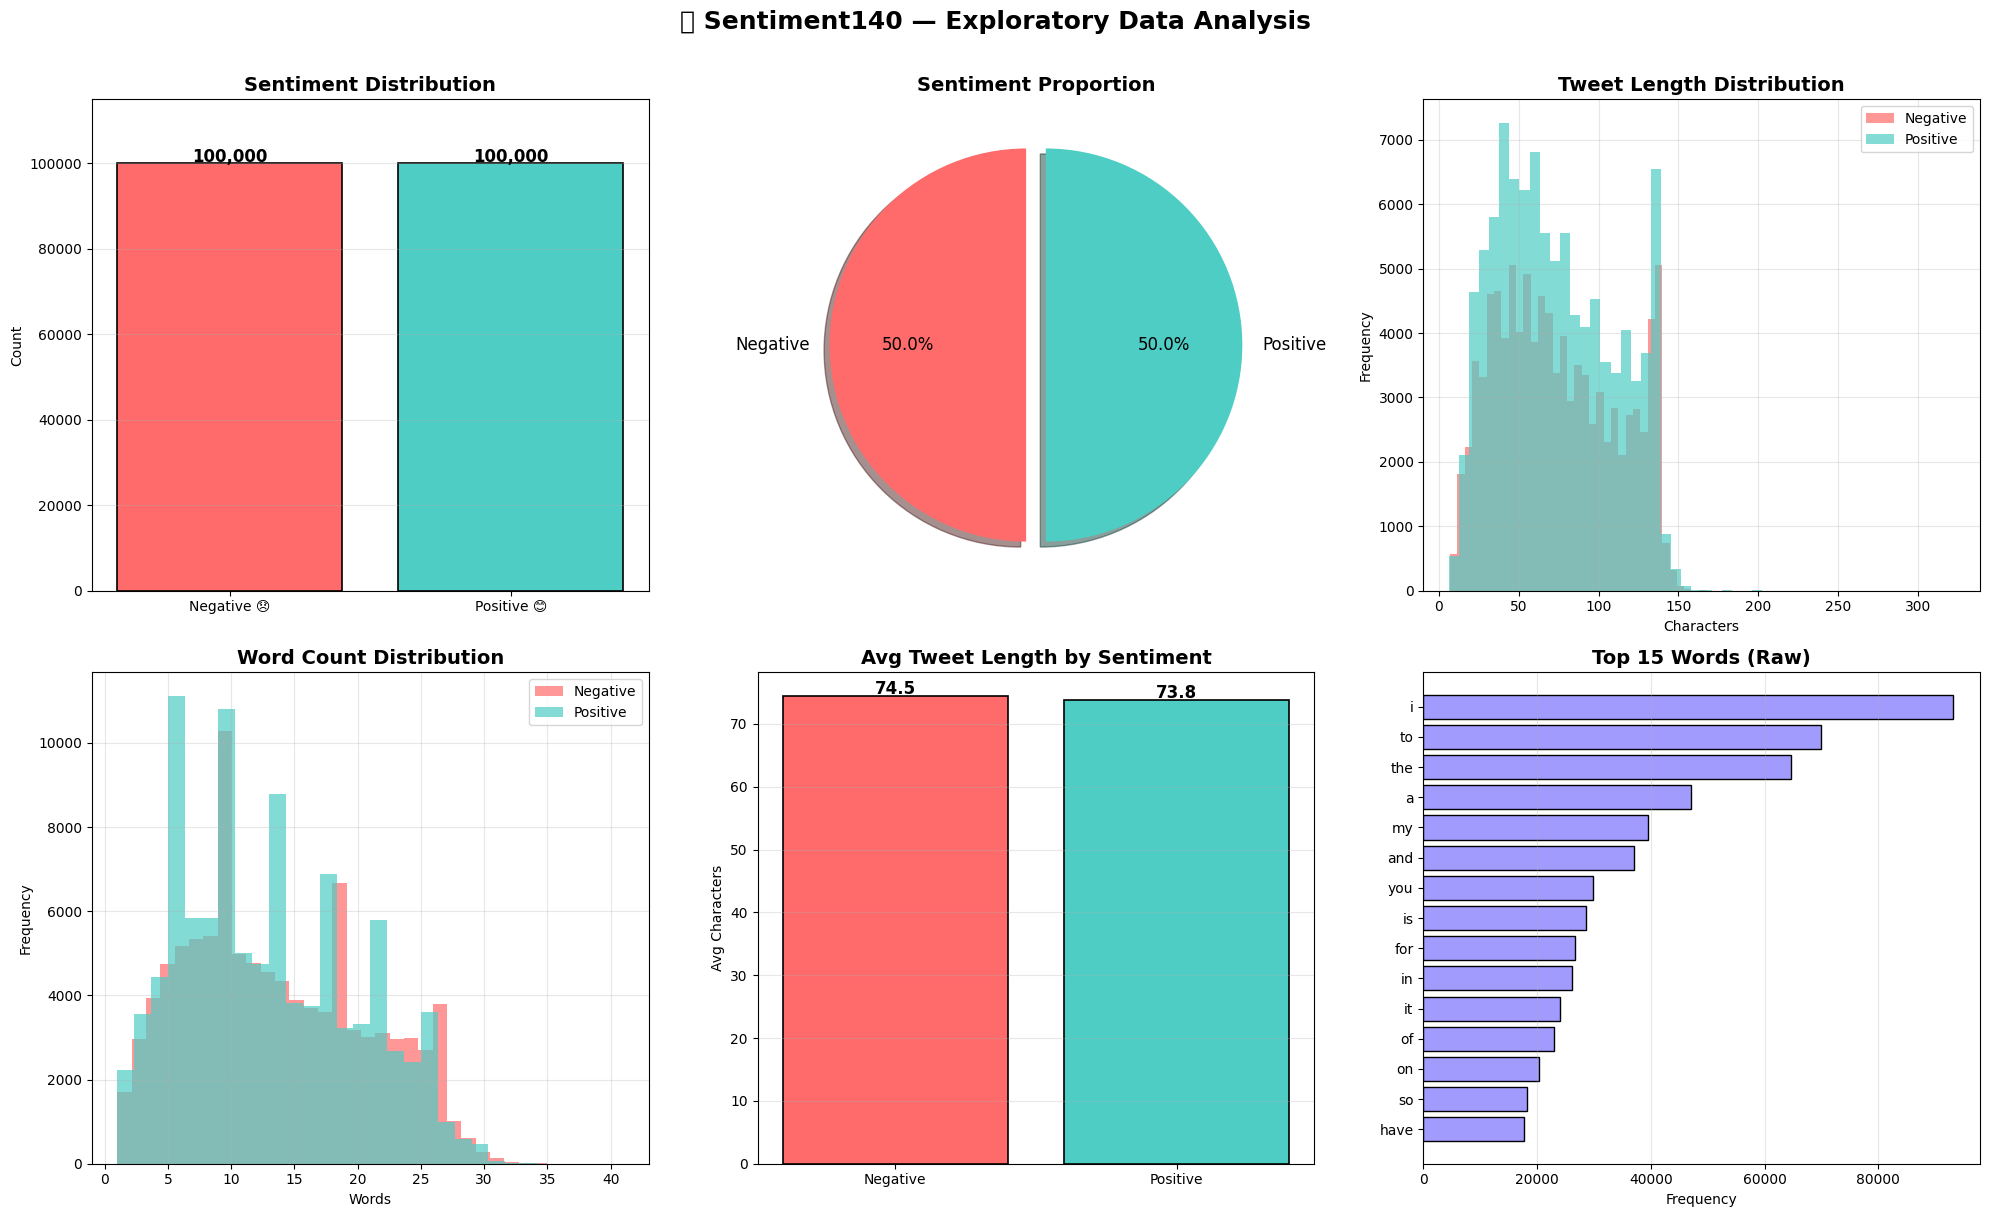

In [ ]:
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('📊 Sentiment140 — Exploratory Data Analysis',
             fontsize=18, fontweight='bold', y=1.01)

colors = ['#FF6B6B', '#4ECDC4']

# 1. Bar — sentiment distribution
ax = axes[0, 0]
cnts = df['sentiment'].value_counts()
bars = ax.bar(['Negative 😞', 'Positive 😊'], cnts.values,
              color=colors, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, cnts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f'{val:,}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, cnts.max() * 1.15)

# 2. Pie
ax = axes[0, 1]
ax.pie(cnts.values, labels=['Negative', 'Positive'],
       autopct='%1.1f%%', colors=colors,
       explode=(0.05, 0.05), shadow=True, startangle=90,
       textprops={'fontsize': 12})
ax.set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

# 3. Tweet length histogram
ax = axes[0, 2]
ax.hist(df[df['sentiment']==0]['text_length'], bins=50,
        alpha=0.7, color='#FF6B6B', label='Negative')
ax.hist(df[df['sentiment']==1]['text_length'], bins=50,
        alpha=0.7, color='#4ECDC4', label='Positive')
ax.set_title('Tweet Length Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Characters'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(alpha=0.3)

# 4. Word count histogram
ax = axes[1, 0]
ax.hist(df[df['sentiment']==0]['word_count'], bins=30,
        alpha=0.7, color='#FF6B6B', label='Negative')
ax.hist(df[df['sentiment']==1]['word_count'], bins=30,
        alpha=0.7, color='#4ECDC4', label='Positive')
ax.set_title('Word Count Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Words'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(alpha=0.3)

# 5. Average length by sentiment
ax = axes[1, 1]
avg = df.groupby('sentiment')['text_length'].mean()
b2  = ax.bar(['Negative', 'Positive'], avg.values,
             color=colors, edgecolor='black', linewidth=1.2)
for bar, val in zip(b2, avg.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Avg Tweet Length by Sentiment', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Characters'); ax.grid(axis='y', alpha=0.3)

# 6. Top 15 raw words
ax = axes[1, 2]
raw_freq = Counter(' '.join(df['text'].tolist()).lower().split()).most_common(15)
words, freqs = zip(*raw_freq)
ax.barh(words[::-1], freqs[::-1], color='#A29BFE', edgecolor='black')
ax.set_title('Top 15 Words (Raw)', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

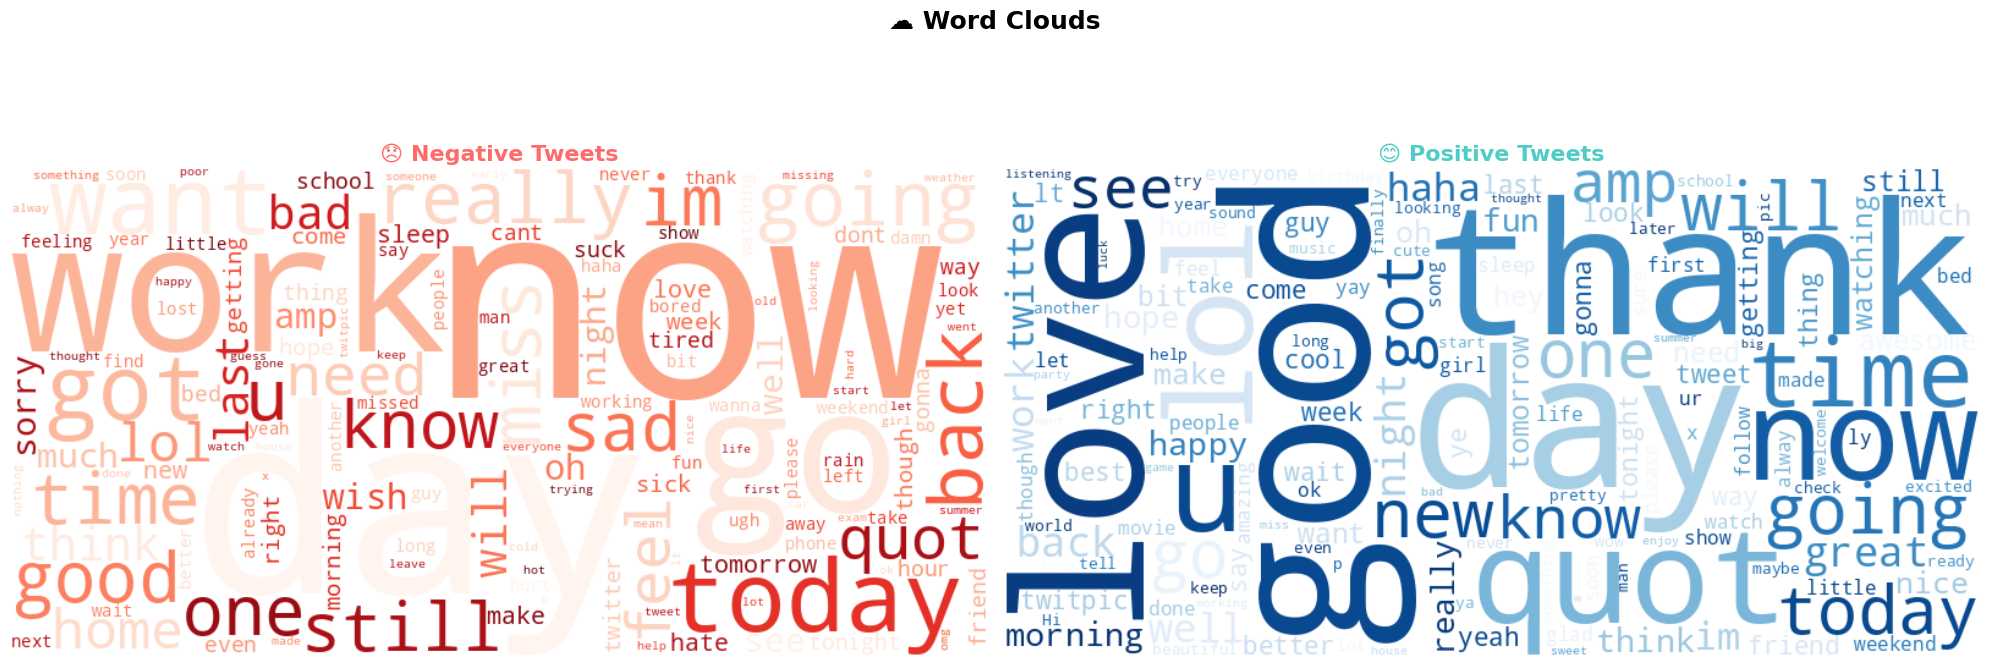

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('☁️ Word Clouds', fontsize=18, fontweight='bold')

for ax, label, cmap, title, color in zip(
    axes,
    [0, 1],
    ['Reds', 'Blues'],
    ['😞 Negative Tweets', '😊 Positive Tweets'],
    ['#FF6B6B', '#4ECDC4']
):
    text = ' '.join(df[df['sentiment'] == label]['text'].tolist())
    wc   = WordCloud(width=800, height=400, background_color='white',
                     colormap=cmap, max_words=150,
                     collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep sentiment-important negation words
keep_words = {'not','no','never','neither','nor',
              'but','very','too','more','most','less'}
stop_words = stop_words - keep_words

# ---------- helpers ----------
def clean_text(text: str) -> str:
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)                        # mentions
    text = re.sub(r'#', '', text)                           # hashtag sym
    text = re.sub(r'<.*?>', '', text)                       # HTML
    text = re.sub(r'[^a-zA-Z\s]', '', text)                # non-alpha
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def full_preprocess(text: str,
                    use_stemming: bool = False,
                    use_lemmatization: bool = True) -> str:
    cleaned = clean_text(text)
    tokens  = word_tokenize(cleaned)
    tokens  = [t for t in tokens
               if t not in stop_words and len(t) > 1]
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    elif use_lemmatization:
        tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return ' '.join(tokens)

# ---------- demo ----------
sample = "I @user love this product! It's amazing! http://x.com #happy 😊"
print("📝 Preprocessing Demo")
print(f"  Original  : {sample}")
print(f"  Cleaned   : {clean_text(sample)}")
toks = word_tokenize(clean_text(sample))
print(f"  Tokenized : {toks}")
toks_ns = [t for t in toks if t not in stop_words and len(t)>1]
print(f"  No StopWd : {toks_ns}")
print(f"  Stemmed   : {[stemmer.stem(t) for t in toks_ns]}")
print(f"  Lemmatized: {[lemmatizer.lemmatize(t,'v') for t in toks_ns]}")
print(f"  Final     : {full_preprocess(sample)}")

📝 Preprocessing Demo
  Original  : I @user love this product! It's amazing! http://x.com #happy 😊
  Cleaned   : i love this product its amazing happy
  Tokenized : ['i', 'love', 'this', 'product', 'its', 'amazing', 'happy']
  No StopWd : ['love', 'product', 'amazing', 'happy']
  Stemmed   : ['love', 'product', 'amaz', 'happi']
  Lemmatized: ['love', 'product', 'amaze', 'happy']
  Final     : love product amaze happy


In [ ]:
print(f"⚙️  Preprocessing {len(df):,} tweets (lemmatization)…")
t0 = time.time()

df['cleaned_text'] = df['text'].apply(
    lambda x: full_preprocess(x, use_lemmatization=True))

print(f"✅ Done in {time.time()-t0:.1f}s")

# Drop empty rows
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print(f"✅ After removing empties : {len(df):,} rows")

# Quick preview
print("\n📋 Sample comparison:")
print("-" * 70)
for i in range(3):
    print(f"Original : {df['text'].iloc[i][:80]}")
    print(f"Cleaned  : {df['cleaned_text'].iloc[i][:80]}")
    lbl = 'Positive 😊' if df['sentiment'].iloc[i] else 'Negative 😞'
    print(f"Label    : {lbl}")
    print("-" * 70)

⚙️  Preprocessing 200,000 tweets (lemmatization)…
✅ Done in 30.7s
✅ After removing empties : 199,172 rows

📋 Sample comparison:
----------------------------------------------------------------------
Original : Looks like the sun finally located Trondheim ;-) hope summer's on it's way 
Cleaned  : look like sun finally locate trondheim hope summer way
Label    : Positive 😊
----------------------------------------------------------------------
Original : A long weekend begins. The sun is shining and I'm happy ! Exams soon 
Cleaned  : long weekend begin sun shin im happy exams soon
Label    : Negative 😞
----------------------------------------------------------------------
Original : to the beach we go! hope it stays nice... 
Cleaned  : beach go hope stay nice
Label    : Positive 😊
----------------------------------------------------------------------


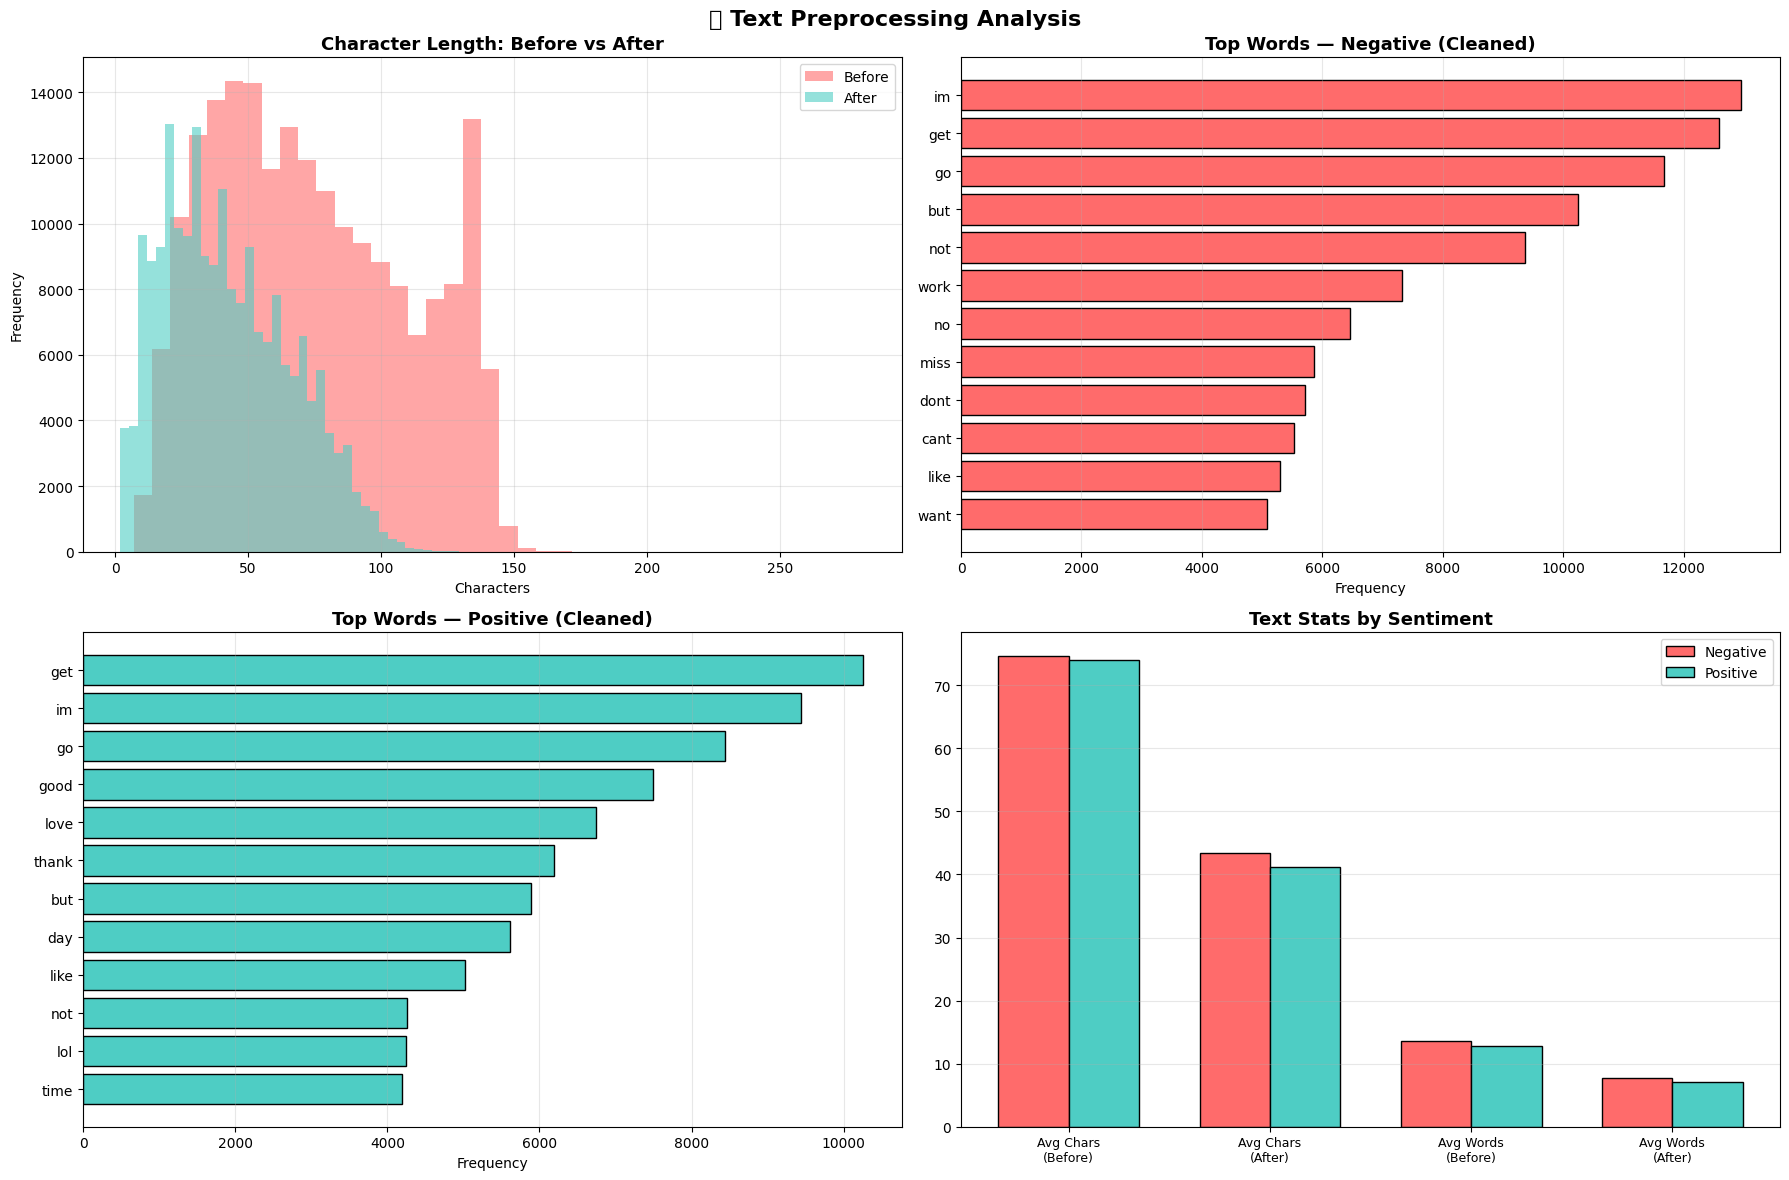

In [ ]:
df['clean_len']  = df['cleaned_text'].apply(len)
df['clean_wc']   = df['cleaned_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('📊 Text Preprocessing Analysis',
             fontsize=16, fontweight='bold')

# 1. Length before vs after
ax = axes[0, 0]
ax.hist(df['text_length'],  bins=40, alpha=0.6, color='#FF6B6B', label='Before')
ax.hist(df['clean_len'],    bins=40, alpha=0.6, color='#4ECDC4', label='After')
ax.set_title('Character Length: Before vs After', fontsize=13, fontweight='bold')
ax.set_xlabel('Characters'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(alpha=0.3)

# 2. Top words — negative (cleaned)
ax = axes[0, 1]
neg_w = Counter(' '.join(
    df[df['sentiment']==0]['cleaned_text']).split()).most_common(12)
ws, cs = zip(*neg_w)
ax.barh(ws[::-1], cs[::-1], color='#FF6B6B', edgecolor='black')
ax.set_title('Top Words — Negative (Cleaned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)

# 3. Top words — positive (cleaned)
ax = axes[1, 0]
pos_w = Counter(' '.join(
    df[df['sentiment']==1]['cleaned_text']).split()).most_common(12)
ws, cs = zip(*pos_w)
ax.barh(ws[::-1], cs[::-1], color='#4ECDC4', edgecolor='black')
ax.set_title('Top Words — Positive (Cleaned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)

# 4. Stats bar chart
ax = axes[1, 1]
metrics  = ['Avg Chars\n(Before)', 'Avg Chars\n(After)',
            'Avg Words\n(Before)', 'Avg Words\n(After)']
neg_vals = [df[df['sentiment']==0]['text_length'].mean(),
            df[df['sentiment']==0]['clean_len'].mean(),
            df[df['sentiment']==0]['word_count'].mean(),
            df[df['sentiment']==0]['clean_wc'].mean()]
pos_vals = [df[df['sentiment']==1]['text_length'].mean(),
            df[df['sentiment']==1]['clean_len'].mean(),
            df[df['sentiment']==1]['word_count'].mean(),
            df[df['sentiment']==1]['clean_wc'].mean()]
x     = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, neg_vals, w, label='Negative', color='#FF6B6B', edgecolor='black')
ax.bar(x + w/2, pos_vals, w, label='Positive',  color='#4ECDC4', edgecolor='black')
ax.set_title('Text Stats by Sentiment', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=9)
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
X = df['cleaned_text'].values
y = df['sentiment'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("📊 Dataset Splits")
print(f"   Train : {len(X_train):>8,}  pos={y_train.mean()*100:.1f}%")
print(f"   Val   : {len(X_val):>8,}  pos={y_val.mean()*100:.1f}%")
print(f"   Test  : {len(X_test):>8,}  pos={y_test.mean()*100:.1f}%")

model_results = {}
print("\n✅ X_train, y_train … X_test, y_test — all ready!")

📊 Dataset Splits
   Train :  139,420  pos=50.0%
   Val   :   29,876  pos=50.0%
   Test  :   29,876  pos=50.0%

✅ X_train, y_train … X_test, y_test — all ready!


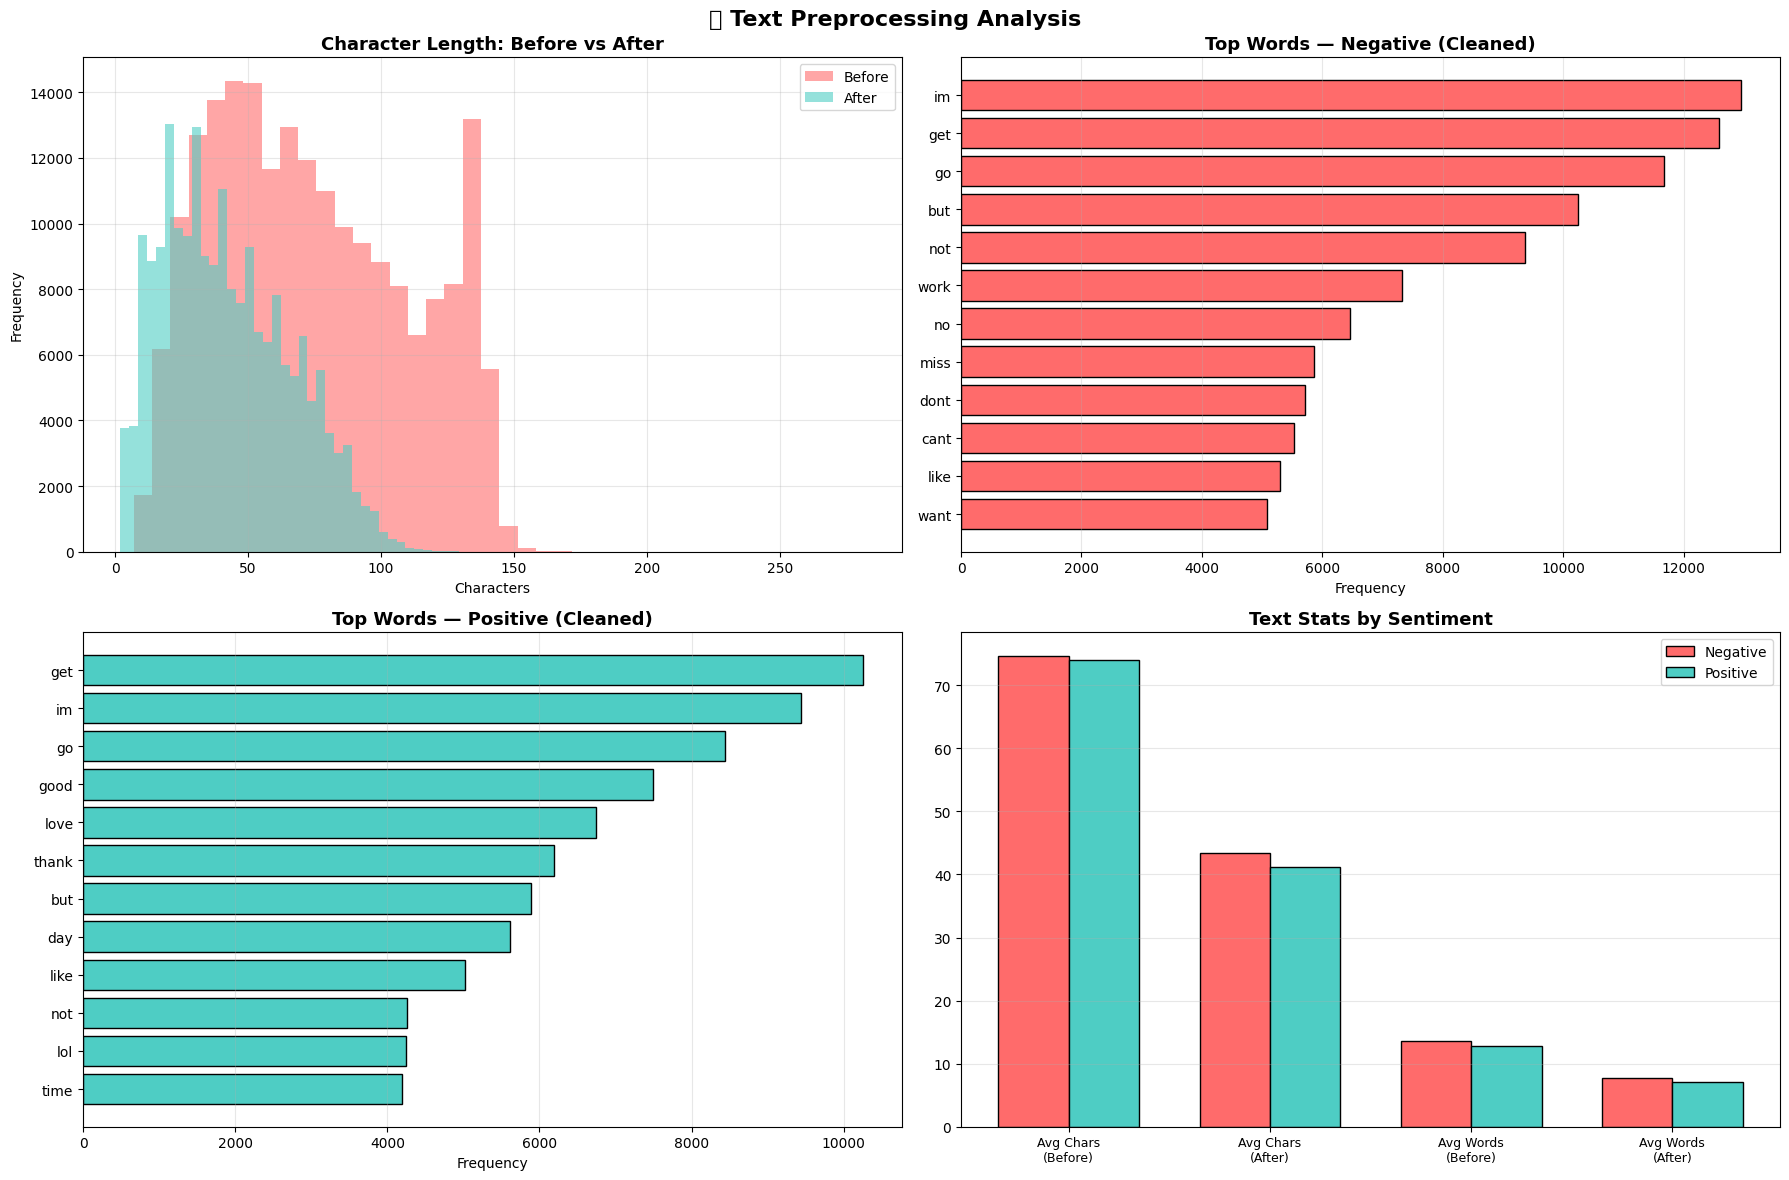

In [ ]:
df['clean_len']  = df['cleaned_text'].apply(len)
df['clean_wc']   = df['cleaned_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('📊 Text Preprocessing Analysis',
             fontsize=16, fontweight='bold')

# 1. Length before vs after
ax = axes[0, 0]
ax.hist(df['text_length'],  bins=40, alpha=0.6, color='#FF6B6B', label='Before')
ax.hist(df['clean_len'],    bins=40, alpha=0.6, color='#4ECDC4', label='After')
ax.set_title('Character Length: Before vs After', fontsize=13, fontweight='bold')
ax.set_xlabel('Characters'); ax.set_ylabel('Frequency')
ax.legend(); ax.grid(alpha=0.3)

# 2. Top words — negative (cleaned)
ax = axes[0, 1]
neg_w = Counter(' '.join(
    df[df['sentiment']==0]['cleaned_text']).split()).most_common(12)
ws, cs = zip(*neg_w)
ax.barh(ws[::-1], cs[::-1], color='#FF6B6B', edgecolor='black')
ax.set_title('Top Words — Negative (Cleaned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)

# 3. Top words — positive (cleaned)
ax = axes[1, 0]
pos_w = Counter(' '.join(
    df[df['sentiment']==1]['cleaned_text']).split()).most_common(12)
ws, cs = zip(*pos_w)
ax.barh(ws[::-1], cs[::-1], color='#4ECDC4', edgecolor='black')
ax.set_title('Top Words — Positive (Cleaned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.3)

# 4. Stats bar chart
ax = axes[1, 1]
metrics  = ['Avg Chars\n(Before)', 'Avg Chars\n(After)',
            'Avg Words\n(Before)', 'Avg Words\n(After)']
neg_vals = [df[df['sentiment']==0]['text_length'].mean(),
            df[df['sentiment']==0]['clean_len'].mean(),
            df[df['sentiment']==0]['word_count'].mean(),
            df[df['sentiment']==0]['clean_wc'].mean()]
pos_vals = [df[df['sentiment']==1]['text_length'].mean(),
            df[df['sentiment']==1]['clean_len'].mean(),
            df[df['sentiment']==1]['word_count'].mean(),
            df[df['sentiment']==1]['clean_wc'].mean()]
x     = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, neg_vals, w, label='Negative', color='#FF6B6B', edgecolor='black')
ax.bar(x + w/2, pos_vals, w, label='Positive',  color='#4ECDC4', edgecolor='black')
ax.set_title('Text Stats by Sentiment', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=9)
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
X = df['cleaned_text'].values
y = df['sentiment'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("📊 Dataset Splits")
print(f"   Train : {len(X_train):>8,}  pos={y_train.mean()*100:.1f}%")
print(f"   Val   : {len(X_val):>8,}  pos={y_val.mean()*100:.1f}%")
print(f"   Test  : {len(X_test):>8,}  pos={y_test.mean()*100:.1f}%")

model_results = {}
print("\n✅ X_train, y_train … X_test, y_test — all ready!")

📊 Dataset Splits
   Train :  139,420  pos=50.0%
   Val   :   29,876  pos=50.0%
   Test  :   29,876  pos=50.0%

✅ X_train, y_train … X_test, y_test — all ready!


In [ ]:
MAX_FEATURES  = 50_000
MAX_LEN       = 50
EMBEDDING_DIM = 100

print("⚙️  Fitting TF-IDF Vectorizer …")
tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"✅ TF-IDF shapes:")
print(f"   Train : {X_train_tfidf.shape}")
print(f"   Val   : {X_val_tfidf.shape}")
print(f"   Test  : {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n📌 Total features : {len(feature_names):,}")

# Save
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✅ tfidf_vectorizer.pkl saved")

⚙️  Fitting TF-IDF Vectorizer …
✅ TF-IDF shapes:
   Train : (139420, 50000)
   Val   : (29876, 50000)
   Test  : (29876, 50000)

📌 Total features : 50,000
✅ tfidf_vectorizer.pkl saved


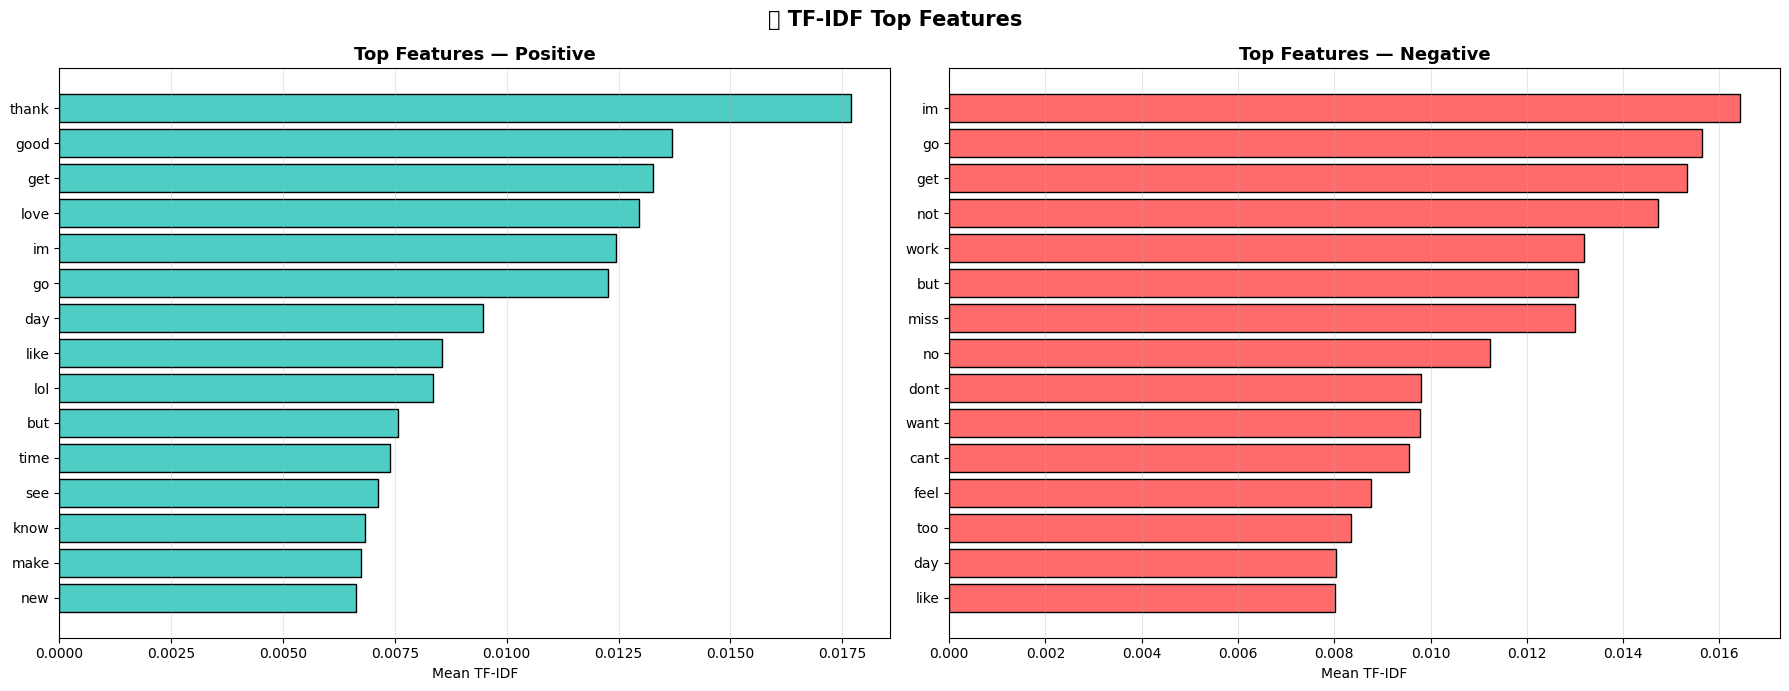

In [ ]:
pos_mask = y_train == 1
neg_mask = y_train == 0

pos_mean = X_train_tfidf[pos_mask].mean(axis=0).A1
neg_mean = X_train_tfidf[neg_mask].mean(axis=0).A1

top_pos = np.argsort(pos_mean)[-15:]
top_neg = np.argsort(neg_mean)[-15:]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('📊 TF-IDF Top Features', fontsize=15, fontweight='bold')

axes[0].barh([feature_names[i] for i in top_pos],
             pos_mean[top_pos], color='#4ECDC4', edgecolor='black')
axes[0].set_title('Top Features — Positive', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF'); axes[0].grid(axis='x', alpha=0.3)

axes[1].barh([feature_names[i] for i in top_neg],
             neg_mean[top_neg], color='#FF6B6B', edgecolor='black')
axes[1].set_title('Top Features — Negative', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF'); axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('tfidf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("⚙️  Preparing corpus …")
all_tokens = [text.split() for text in X_train]

print("⚙️  Training Word2Vec (Skip-gram, 100d) …")
t0 = time.time()
w2v_model = Word2Vec(
    sentences=all_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    sg=1,
    negative=5
)
print(f"✅ Done in {time.time()-t0:.1f}s")
print(f"   Vocabulary : {len(w2v_model.wv):,}")

# Similarity demo
print("\n📊 Word2Vec similarity examples:")
for word in ['love', 'hate', 'happy', 'sad', 'good', 'bad']:
    if word in w2v_model.wv:
        sims = w2v_model.wv.most_similar(word, topn=4)
        print(f"  '{word}' → {[(w, round(s,3)) for w,s in sims]}")

w2v_model.save('word2vec_model.bin')

⚙️  Preparing corpus …
⚙️  Training Word2Vec (Skip-gram, 100d) …
✅ Done in 36.8s
   Vocabulary : 23,904

📊 Word2Vec similarity examples:
  'love' → [('iloveyou', 0.709), ('loove', 0.7), ('lovee', 0.695), ('thankss', 0.678)]
  'hate' → [('stupid', 0.622), ('suck', 0.607), ('despise', 0.604), ('hat', 0.586)]
  'happy' → [('belated', 0.688), ('mommies', 0.68), ('andyhurleyday', 0.663), ('bmore', 0.658)]
  'sad' → [('depress', 0.666), ('pervert', 0.659), ('homesick', 0.651), ('heartbroken', 0.65)]
  'good' → [('goooood', 0.8), ('gooood', 0.77), ('goood', 0.758), ('gooooood', 0.731)]
  'bad' → [('sucky', 0.607), ('earlyy', 0.599), ('icky', 0.597), ('horrible', 0.59)]


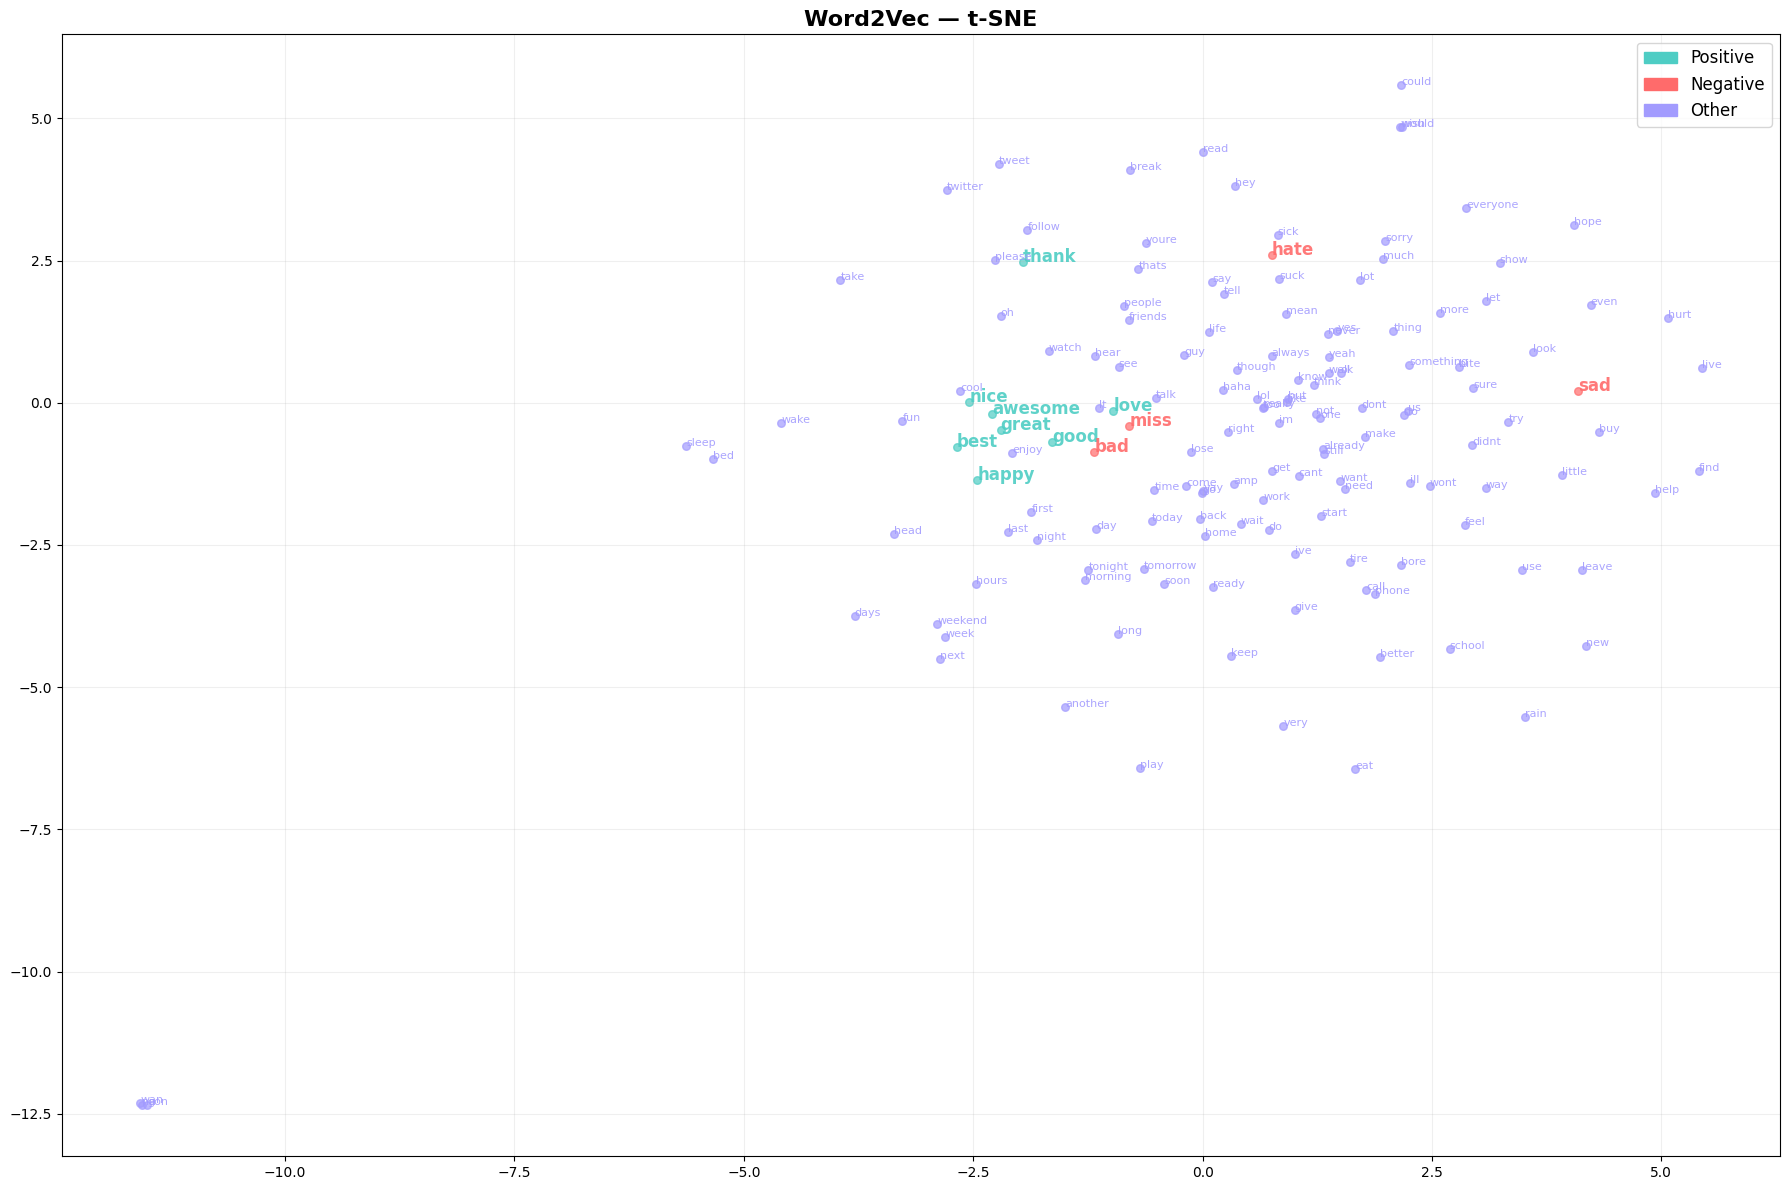

In [ ]:
from sklearn.manifold import TSNE

top_vocab = Counter(' '.join(X_train).split()).most_common(200)
top_words = [w for w, _ in top_vocab if w in w2v_model.wv][:150]
vectors   = np.array([w2v_model.wv[w] for w in top_words])

tsne     = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
vecs_2d  = tsne.fit_transform(vectors)

pos_set = {'love','good','great','happy','best','wonderful','amazing',
           'excellent','awesome','thank','nice'}
neg_set = {'hate','bad','sad','miss','wrong','poor','terrible',
           'awful','horrible','worst','fail'}

fig, ax = plt.subplots(figsize=(18, 12))
for i, word in enumerate(top_words):
    x, y_  = vecs_2d[i]
    if   word in pos_set: col, sz, wt = '#4ECDC4', 12, 'bold'
    elif word in neg_set: col, sz, wt = '#FF6B6B', 12, 'bold'
    else:                 col, sz, wt = '#A29BFE',  8, 'normal'
    ax.scatter(x, y_, c=col, s=30, alpha=0.7)
    ax.annotate(word, (x, y_), fontsize=sz, fontweight=wt,
                color=col, alpha=0.9)

handles = [mpatches.Patch(color='#4ECDC4', label='Positive'),
           mpatches.Patch(color='#FF6B6B', label='Negative'),
           mpatches.Patch(color='#A29BFE', label='Other')]
ax.legend(handles=handles, fontsize=12, loc='upper right')
ax.set_title('Word2Vec — t-SNE', fontsize=16, fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('word2vec_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
if not os.path.exists('glove/glove.6B.100d.txt'):
    print("📥 Downloading GloVe 6B 100d …")
    !wget -q --show-progress http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q glove.6B.zip -d glove/
    print("✅ GloVe downloaded!")
else:
    print("✅ GloVe already present — skipping download")

GLOVE_PATH = 'glove/glove.6B.100d.txt'
print("⚙️  Loading GloVe vectors …")
glove_embeddings = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        vals  = line.split()
        word  = vals[0]
        vec   = np.asarray(vals[1:], dtype='float32')
        glove_embeddings[word] = vec

print(f"✅ GloVe loaded : {len(glove_embeddings):,} vectors")

📥 Downloading GloVe 6B 100d …
glove.6B.zip        100%[===================>] 822.24M  2.88MB/s    in 11m 19s 
✅ GloVe downloaded!
⚙️  Loading GloVe vectors …
✅ GloVe loaded : 400,000 vectors


In [ ]:
print("⚙️  Fitting Keras Tokenizer …")
keras_tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train)
word_index = keras_tokenizer.word_index
print(f"✅ Vocabulary : {len(word_index):,}  (capped at {MAX_FEATURES:,})")

# Sequences → Padded
X_train_pad = pad_sequences(
    keras_tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(
    keras_tokenizer.texts_to_sequences(X_val),
    maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(
    keras_tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\n✅ Padded shapes:")
print(f"   Train : {X_train_pad.shape}")
print(f"   Val   : {X_val_pad.shape}")
print(f"   Test  : {X_test_pad.shape}")

# GloVe Embedding Matrix
print("\n⚙️  Building GloVe embedding matrix …")
embedding_matrix = np.zeros((MAX_FEATURES + 1, EMBEDDING_DIM))
found = 0
for word, idx in word_index.items():
    if idx <= MAX_FEATURES:
        vec = glove_embeddings.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec
            found += 1

coverage = found / min(len(word_index), MAX_FEATURES) * 100
print(f"✅ Embedding matrix : {embedding_matrix.shape}")
print(f"   GloVe coverage   : {coverage:.1f}%  ({found:,} words)")

# Save tokenizer
with open('keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tokenizer, f)
print("✅ keras_tokenizer.pkl saved")

⚙️  Fitting Keras Tokenizer …
✅ Vocabulary : 74,482  (capped at 50,000)

✅ Padded shapes:
   Train : (139420, 50)
   Val   : (29876, 50)
   Test  : (29876, 50)

⚙️  Building GloVe embedding matrix …
✅ Embedding matrix : (50001, 100)
   GloVe coverage   : 51.0%  (25,502 words)
✅ keras_tokenizer.pkl saved


In [ ]:
def plot_history(history, model_name: str, save_name: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'📊 {model_name} — Training History',
                 fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],
                 label='Train', color='#4ECDC4', linewidth=2)
    axes[0].plot(history.history['val_accuracy'],
                 label='Val',   color='#FF6B6B', linewidth=2)
    axes[0].set_title('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],
                 label='Train', color='#4ECDC4', linewidth=2)
    axes[1].plot(history.history['val_loss'],
                 label='Val',   color='#FF6B6B', linewidth=2)
    axes[1].set_title('Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Plot saved : {save_name}")

print("✅ plot_history ready!")

✅ plot_history ready!


📊 Building ANN …


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │    25,600,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,776,641 (98.33 MB)

 Trainable params: 25,774,849 (98.32 MB)

 Non-trainable params: 1,792 (7.00 KB)


🚀 Training ANN …
Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 189s 5s/step - accuracy: 0.6905 - loss: 0.6131 - val_accuracy: 0.5003 - val_loss: 0.6834 - learning_rate: 0.0010
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 182s 5s/step - accuracy: 0.8153 - loss: 0.4108 - val_accuracy: 0.5072 - val_loss: 0.6759 - learning_rate: 0.0010
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 176s 5s/step - accuracy: 0.8650 - loss: 0.3131 - val_accuracy: 0.5026 - val_loss: 0.6773 - learning_rate: 0.0010
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 167s 5s/step - accuracy: 0.9085 - loss: 0.2241 - val_accuracy: 0.5154 - val_loss: 0.6647 - learning_rate: 0.0010
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 176s 5s/step - accuracy: 0.9393 - loss: 0.1538 - val_accuracy: 0.5907 - val_loss: 0.6340 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 234ms/step

✅ ANN  Accuracy=0.5860  F1=0.3072
              precision    recall  f1-score   support

    Negative       0.55      0.99      0.

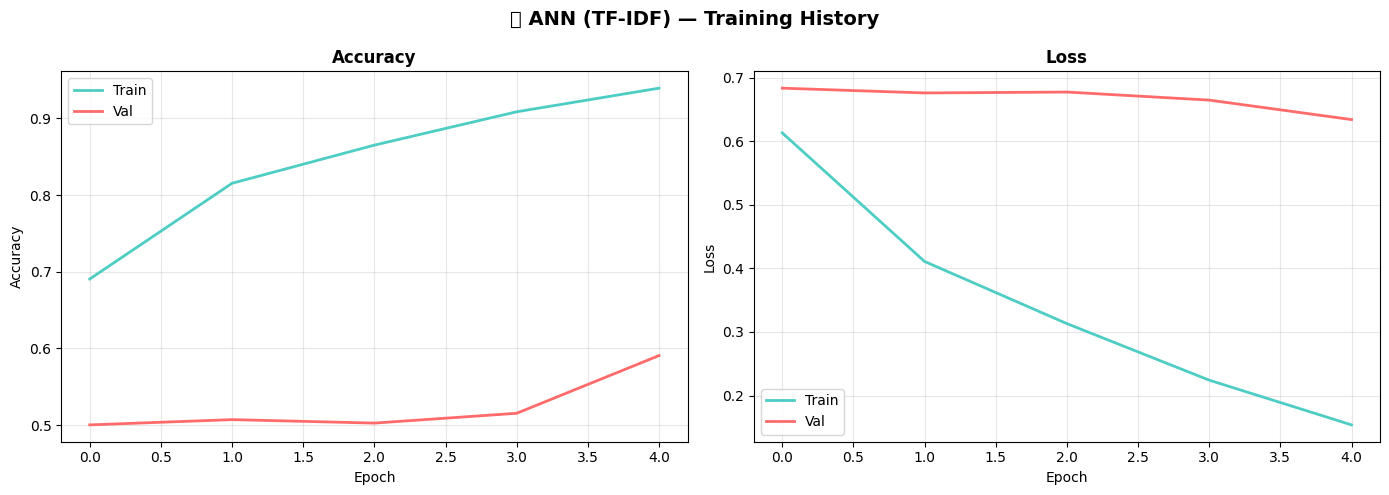

✅ Plot saved : ann_history.png
✅ ann_model.h5 saved!


In [ ]:
def build_ann_model(input_dim: int):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu'),
        BatchNormalization(), Dropout(0.4),
        Dense(256, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(), Dropout(0.3),
        Dense(64,  activation='relu'), Dropout(0.2),
        Dense(1,   activation='sigmoid')
    ])
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("📊 Building ANN …")
ann_model = build_ann_model(X_train_tfidf.shape[1])
ann_model.summary()

cb_ann = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("\n🚀 Training ANN …")
ann_history = ann_model.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=5, batch_size=4096,
    callbacks=cb_ann, verbose=1
)

y_pred_ann = (ann_model.predict(X_test_tfidf, batch_size=512) > 0.5
              ).astype(int).flatten()
ann_acc = accuracy_score(y_test, y_pred_ann)
ann_f1  = f1_score(y_test, y_pred_ann)

model_results['ANN (TF-IDF)'] = {
    'accuracy' : ann_acc,
    'f1_score' : ann_f1,
    'precision': precision_score(y_test, y_pred_ann),
    'recall'   : recall_score(y_test, y_pred_ann)
}

print(f"\n✅ ANN  Accuracy={ann_acc:.4f}  F1={ann_f1:.4f}")
print(classification_report(y_test, y_pred_ann,
                             target_names=['Negative','Positive']))

plot_history(ann_history, 'ANN (TF-IDF)', 'ann_history.png')
ann_model.save('ann_model.h5')
print("✅ ann_model.h5 saved!")

📊 Building CNN …


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 100)   │  5,000,100 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 128)   │     25,728 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 128)   │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 128)   │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 128)   │     64,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │        129 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,345,189 (20.39 MB)

 Trainable params: 5,344,677 (20.39 MB)

 Non-trainable params: 512 (2.00 KB)


🚀 Training CNN …
Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 556ms/step - accuracy: 0.6548 - loss: 0.6487 - val_accuracy: 0.7137 - val_loss: 0.5866 - learning_rate: 0.0010
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.7359 - loss: 0.5321 - val_accuracy: 0.7338 - val_loss: 0.5433 - learning_rate: 0.0010
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.7687 - loss: 0.4861 - val_accuracy: 0.7575 - val_loss: 0.5192 - learning_rate: 0.0010
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.7875 - loss: 0.4543 - val_accuracy: 0.7715 - val_loss: 0.4899 - learning_rate: 0.0010
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.8057 - loss: 0.4236 - val_accuracy: 0.7776 - val_loss: 0.4719 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step

✅ CNN  Accuracy=0.7751  F1=0.7709
              precision    recall  f1-score   support

    Negative       0.77      0.79    

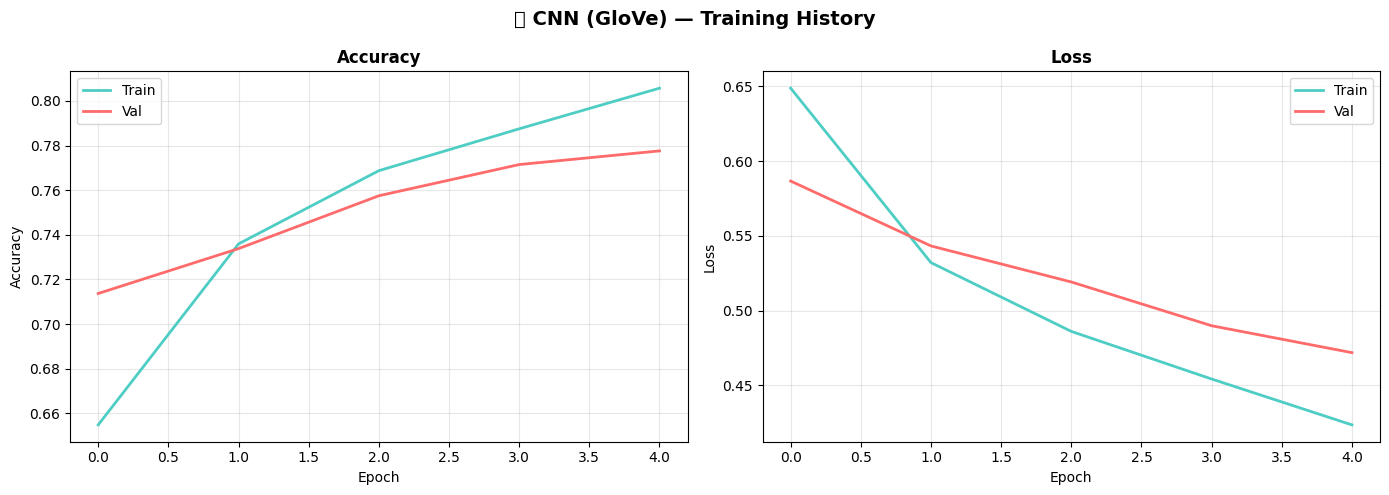

✅ Plot saved : cnn_history.png
✅ cnn_model.h5 saved!


In [ ]:
def build_cnn_model(vocab_size, emb_dim, max_len, emb_matrix=None):
    inp = Input(shape=(max_len,))

    if emb_matrix is not None:
        x = Embedding(vocab_size+1, emb_dim,
                      weights=[emb_matrix],
                      input_length=max_len,
                      trainable=True)(inp)
    else:
        x = Embedding(vocab_size+1, emb_dim,
                      input_length=max_len)(inp)

    # Multi-scale convolutions
    convs = [GlobalMaxPooling1D()(
                Conv1D(128, k, activation='relu', padding='same')(x))
             for k in [2, 3, 4, 5]]

    cat  = Concatenate()(convs)
    out  = Dense(256, activation='relu')(cat)
    out  = BatchNormalization()(out)
    out  = Dropout(0.4)(out)
    out  = Dense(128, activation='relu')(out)
    out  = Dropout(0.3)(out)
    out  = Dense(1, activation='sigmoid')(out)

    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("📊 Building CNN …")
cnn_model = build_cnn_model(MAX_FEATURES, EMBEDDING_DIM,
                             MAX_LEN, embedding_matrix)
cnn_model.summary()

cb_cnn = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("\n🚀 Training CNN …")
cnn_history = cnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5, batch_size=4092,
    callbacks=cb_cnn, verbose=1
)

y_pred_cnn = (cnn_model.predict(X_test_pad, batch_size=512) > 0.5
              ).astype(int).flatten()
cnn_acc = accuracy_score(y_test, y_pred_cnn)
cnn_f1  = f1_score(y_test, y_pred_cnn)

model_results['CNN (GloVe)'] = {
    'accuracy' : cnn_acc,
    'f1_score' : cnn_f1,
    'precision': precision_score(y_test, y_pred_cnn),
    'recall'   : recall_score(y_test, y_pred_cnn)
}

print(f"\n✅ CNN  Accuracy={cnn_acc:.4f}  F1={cnn_f1:.4f}")
print(classification_report(y_test, y_pred_cnn,
                             target_names=['Negative','Positive']))

plot_history(cnn_history, 'CNN (GloVe)', 'cnn_history.png')
cnn_model.save('cnn_model.h5')
print("✅ cnn_model.h5 saved!")

📊 Building SimpleRNN …


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     5,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,000,100 (19.07 MB)

 Trainable params: 5,000,100 (19.07 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Training SimpleRNN …
Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - accuracy: 0.6142 - loss: 0.6514 - val_accuracy: 0.7055 - val_loss: 0.5801 - learning_rate: 0.0010
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.7231 - loss: 0.5553 - val_accuracy: 0.7282 - val_loss: 0.5575 - learning_rate: 0.0010
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.7565 - loss: 0.5163 - val_accuracy: 0.7440 - val_loss: 0.5196 - learning_rate: 0.0010
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.7809 - loss: 0.4788 - val_accuracy: 0.7587 - val_loss: 0.5013 - learning_rate: 0.0010
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.7959 - loss: 0.4543 - val_accuracy: 0.7670 - val_loss: 0.4984 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step

✅ RNN  Accuracy=0.7640  F1=0.7461
              precision    recall  f1-score   support

    Negative       0.73      0.8

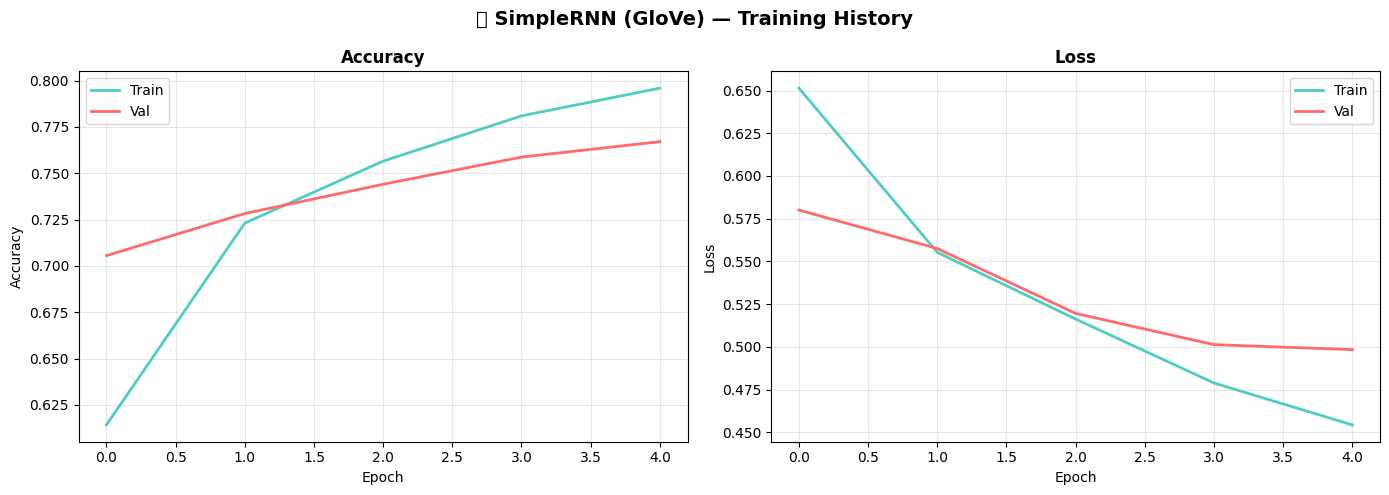

✅ Plot saved : rnn_history.png


In [ ]:
def build_rnn_model(vocab_size, emb_dim, max_len, emb_matrix=None):
    model = Sequential()

    if emb_matrix is not None:
        model.add(Embedding(vocab_size+1, emb_dim,
                            weights=[emb_matrix],
                            input_length=max_len,
                            trainable=True))
    else:
        model.add(Embedding(vocab_size+1, emb_dim,
                            input_length=max_len))

    model.add(SimpleRNN(128, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(SimpleRNN(64))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("📊 Building SimpleRNN …")
rnn_model = build_rnn_model(MAX_FEATURES, EMBEDDING_DIM,
                             MAX_LEN, embedding_matrix)
rnn_model.summary()

cb_rnn = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("\n🚀 Training SimpleRNN …")
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5, batch_size=4092,
    callbacks=cb_rnn, verbose=1
)

y_pred_rnn = (rnn_model.predict(X_test_pad, batch_size=512) > 0.5
              ).astype(int).flatten()
rnn_acc = accuracy_score(y_test, y_pred_rnn)
rnn_f1  = f1_score(y_test, y_pred_rnn)

model_results['SimpleRNN (GloVe)'] = {
    'accuracy' : rnn_acc,
    'f1_score' : rnn_f1,
    'precision': precision_score(y_test, y_pred_rnn),
    'recall'   : recall_score(y_test, y_pred_rnn)
}

print(f"\n✅ RNN  Accuracy={rnn_acc:.4f}  F1={rnn_f1:.4f}")
print(classification_report(y_test, y_pred_rnn,
                             target_names=['Negative','Positive']))

plot_history(rnn_history, 'SimpleRNN (GloVe)', 'rnn_history.png')
rnn_model.save('rnn_model.h5')

📊 Building BiLSTM …


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 100)        │     5,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,424,293 (20.69 MB)

 Trainable params: 5,424,037 (20.69 MB)

 Non-trainable params: 256 (1.00 KB)


🚀 Training BiLSTM …
Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 54s 971ms/step - accuracy: 0.6271 - loss: 0.6604 - val_accuracy: 0.6125 - val_loss: 0.6690 - learning_rate: 0.0010
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 900ms/step - accuracy: 0.7224 - loss: 0.5509 - val_accuracy: 0.6768 - val_loss: 0.6482 - learning_rate: 0.0010
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 34s 979ms/step - accuracy: 0.7533 - loss: 0.5098 - val_accuracy: 0.7308 - val_loss: 0.6316 - learning_rate: 0.0010
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 890ms/step - accuracy: 0.7710 - loss: 0.4851 - val_accuracy: 0.7203 - val_loss: 0.6091 - learning_rate: 0.0010
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 946ms/step - accuracy: 0.7833 - loss: 0.4661 - val_accuracy: 0.7518 - val_loss: 0.5766 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step

✅ BiLSTM  Accuracy=0.7501  F1=0.7012
              precision    recall  f1-score   support

    Negative       0.69  

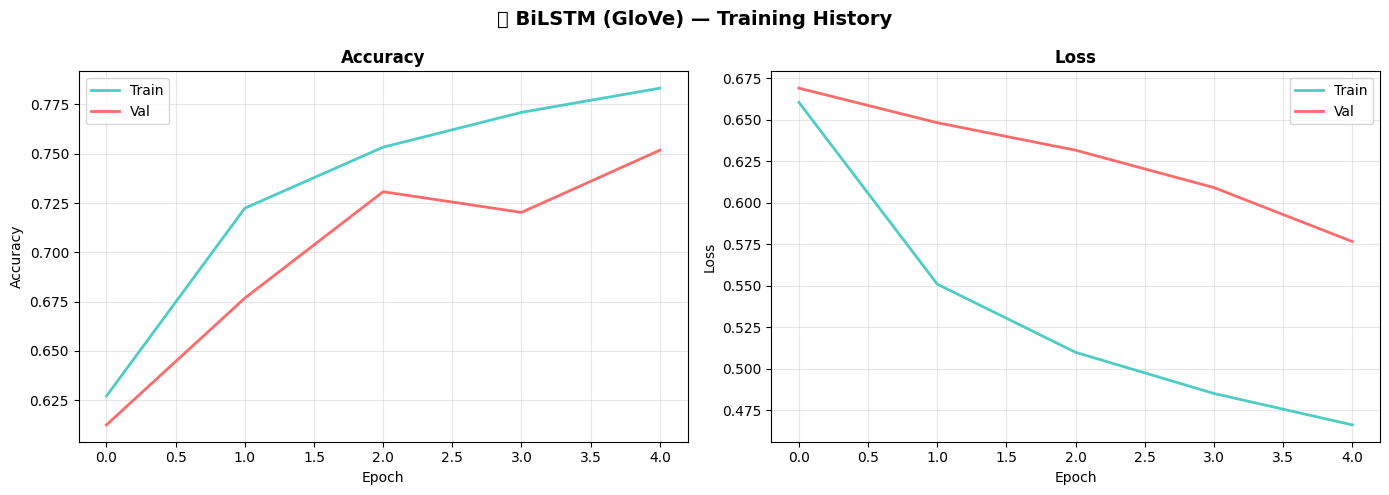

✅ Plot saved : lstm_history.png


In [ ]:
# Explicit imports — prevents NameError after session reset
from tensorflow.keras.layers import LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_lstm_model(vocab_size, emb_dim, max_len, emb_matrix=None):
    inp = Input(shape=(max_len,))

    if emb_matrix is not None:
        x = Embedding(vocab_size+1, emb_dim,
                      weights=[emb_matrix],
                      input_length=max_len,
                      trainable=True)(inp)
    else:
        x = Embedding(vocab_size+1, emb_dim,
                      input_length=max_len)(inp)

    x = Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1))(x)
    x = Bidirectional(LSTM(64,  return_sequences=False,
                           dropout=0.2, recurrent_dropout=0.1))(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("📊 Building BiLSTM …")
lstm_model = build_lstm_model(MAX_FEATURES, EMBEDDING_DIM,
                               MAX_LEN, embedding_matrix)
lstm_model.summary()

cb_lstm = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("\n🚀 Training BiLSTM …")
lstm_history = lstm_model.fit(
    X_train_pad, y_train,                  # ✅ FIXED: X_train_pad (not x_train)
    validation_data=(X_val_pad, y_val),
    epochs=5, batch_size=4096,
    callbacks=cb_lstm, verbose=1
)

y_pred_lstm = (lstm_model.predict(X_test_pad, batch_size=512) > 0.5
               ).astype(int).flatten()
lstm_acc = accuracy_score(y_test, y_pred_lstm)
lstm_f1  = f1_score(y_test, y_pred_lstm)

model_results['BiLSTM (GloVe)'] = {
    'accuracy' : lstm_acc,
    'f1_score' : lstm_f1,
    'precision': precision_score(y_test, y_pred_lstm),
    'recall'   : recall_score(y_test, y_pred_lstm)
}

print(f"\n✅ BiLSTM  Accuracy={lstm_acc:.4f}  F1={lstm_f1:.4f}")
print(classification_report(y_test, y_pred_lstm,
                             target_names=['Negative','Positive']))

plot_history(lstm_history, 'BiLSTM (GloVe)', 'lstm_history.png')
lstm_model.save('lstm_model.h5')

📊 Building BiGRU …


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 50, 100)        │     5,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,325,733 (20.32 MB)

 Trainable params: 5,325,477 (20.32 MB)

 Non-trainable params: 256 (1.00 KB)


🚀 Training BiGRU …
Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 902ms/step - accuracy: 0.5982 - loss: 0.7061 - val_accuracy: 0.6883 - val_loss: 0.6636 - learning_rate: 0.0010
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 37s 801ms/step - accuracy: 0.7030 - loss: 0.5743 - val_accuracy: 0.7532 - val_loss: 0.6229 - learning_rate: 0.0010
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 797ms/step - accuracy: 0.7451 - loss: 0.5217 - val_accuracy: 0.7608 - val_loss: 0.5773 - learning_rate: 0.0010
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 27s 781ms/step - accuracy: 0.7666 - loss: 0.4910 - val_accuracy: 0.7736 - val_loss: 0.5371 - learning_rate: 0.0010
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 799ms/step - accuracy: 0.7797 - loss: 0.4709 - val_accuracy: 0.7800 - val_loss: 0.5118 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 191ms/step

✅ BiGRU  Accuracy=0.7783  F1=0.7724
              precision    recall  f1-score   support

    Negative       0.77    

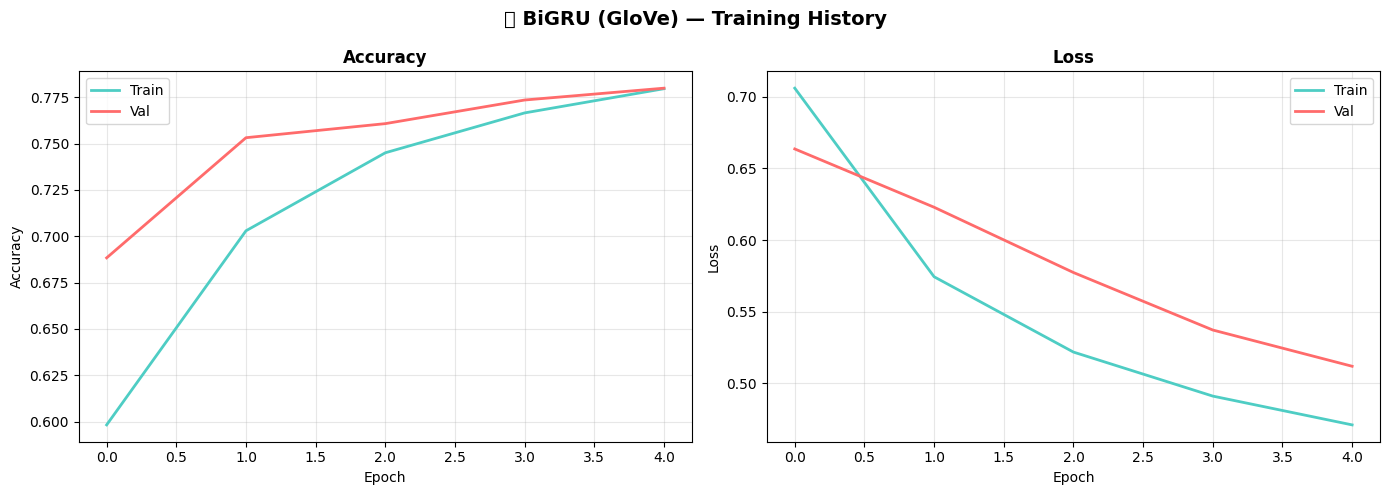

✅ Plot saved : gru_history.png


In [ ]:
# Explicit imports
from tensorflow.keras.layers import GRU, Bidirectional, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_gru_model(vocab_size, emb_dim, max_len, emb_matrix=None):
    inp = Input(shape=(max_len,))

    if emb_matrix is not None:
        x = Embedding(vocab_size+1, emb_dim,
                      weights=[emb_matrix],
                      input_length=max_len,
                      trainable=True)(inp)
    else:
        x = Embedding(vocab_size+1, emb_dim,
                      input_length=max_len)(inp)

    x = Bidirectional(GRU(128, return_sequences=True,      # ✅ GRU imported above
                          dropout=0.2, recurrent_dropout=0.1))(x)
    x = Bidirectional(GRU(64,  return_sequences=False,
                          dropout=0.2, recurrent_dropout=0.1))(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("📊 Building BiGRU …")
gru_model = build_gru_model(MAX_FEATURES, EMBEDDING_DIM,
                             MAX_LEN, embedding_matrix)
gru_model.summary()

cb_gru = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("\n🚀 Training BiGRU …")
gru_history = gru_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5, batch_size=4096,
    callbacks=cb_gru, verbose=1
)

y_pred_gru = (gru_model.predict(X_test_pad, batch_size=512) > 0.5
              ).astype(int).flatten()
gru_acc = accuracy_score(y_test, y_pred_gru)
gru_f1  = f1_score(y_test, y_pred_gru)

model_results['BiGRU (GloVe)'] = {
    'accuracy' : gru_acc,
    'f1_score' : gru_f1,
    'precision': precision_score(y_test, y_pred_gru),
    'recall'   : recall_score(y_test, y_pred_gru)
}

print(f"\n✅ BiGRU  Accuracy={gru_acc:.4f}  F1={gru_f1:.4f}")
print(classification_report(y_test, y_pred_gru,
                             target_names=['Negative','Positive']))

plot_history(gru_history, 'BiGRU (GloVe)', 'gru_history.png')
gru_model.save('gru_model.h5')

In [ ]:
BERT_SAMPLE     = 20_000
BERT_MAX_LEN    = 64
BERT_BATCH_SIZE = 32
BERT_EPOCHS     = 3
BERT_LR         = 2e-5

# Balanced sample
idx_neg  = np.where(y_train == 0)[0][:BERT_SAMPLE // 2]
idx_pos  = np.where(y_train == 1)[0][:BERT_SAMPLE // 2]
idx_bert = np.concatenate([idx_neg, idx_pos])
np.random.shuffle(idx_bert)

X_bert_train = X_train[idx_bert]
y_bert_train = y_train[idx_bert]
X_bert_val   = X_val[:3000]
y_bert_val   = y_val[:3000]
X_bert_test  = X_test[:3000]
y_bert_test  = y_test[:3000]

print(f"📊 BERT Train : {len(X_bert_train):,}")
print(f"📊 BERT Val   : {len(X_bert_val):,}")
print(f"📊 BERT Test  : {len(X_bert_test):,}")

print("\n📥 Loading bert-base-uncased tokenizer …")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("✅ BERT Tokenizer ready!")

# PyTorch Dataset
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'label'         : torch.tensor(self.labels[idx],
                                           dtype=torch.long)
        }

train_dataset = SentimentDataset(X_bert_train, y_bert_train,
                                  bert_tokenizer, BERT_MAX_LEN)
val_dataset   = SentimentDataset(X_bert_val,   y_bert_val,
                                  bert_tokenizer, BERT_MAX_LEN)
test_dataset  = SentimentDataset(X_bert_test,  y_bert_test,
                                  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BERT_BATCH_SIZE * 2)
test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH_SIZE * 2)

print(f"\n✅ DataLoaders ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val   batches : {len(val_loader)}")

📊 BERT Train : 20,000
📊 BERT Val   : 3,000
📊 BERT Test  : 3,000

📥 Loading bert-base-uncased tokenizer …


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ BERT Tokenizer ready!

✅ DataLoaders ready!
   Train batches : 625
   Val   batches : 47


📱 Device : cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🚀 Fine-tuning BERT (3 epochs) …

==================================================  Epoch 1/3
   batch 100/625 loss=0.6122 acc=0.6672
   batch 200/625 loss=0.5684 acc=0.7086
   batch 300/625 loss=0.5405 acc=0.7295
   batch 400/625 loss=0.5307 acc=0.7393
   batch 500/625 loss=0.5203 acc=0.7469
   batch 600/625 loss=0.5079 acc=0.7546
  Train  loss=0.5063  acc=0.7556
  Val    loss=0.4420  acc=0.7950

==================================================  Epoch 2/3
   batch 100/625 loss=0.3826 acc=0.8384
   batch 200/625 loss=0.3796 acc=0.8356
   batch 300/625 loss=0.3741 acc=0.8391
   batch 400/625 loss=0.3749 acc=0.8370
   batch 500/625 loss=0.3802 acc=0.8339
   batch 600/625 loss=0.3811 acc=0.8351
  Train  loss=0.3817  acc=0.8350
  Val    loss=0.4637  acc=0.7913

==================================================  Epoch 3/3
   batch 100/625 loss=0.2475 acc=0.9025
   batch 200/625 loss=0.2653 acc=0.8978
   batch 300/625 loss=0.2644 acc=0.8970
   batch 400/625 loss=0.2635 acc=0.8977
   bat

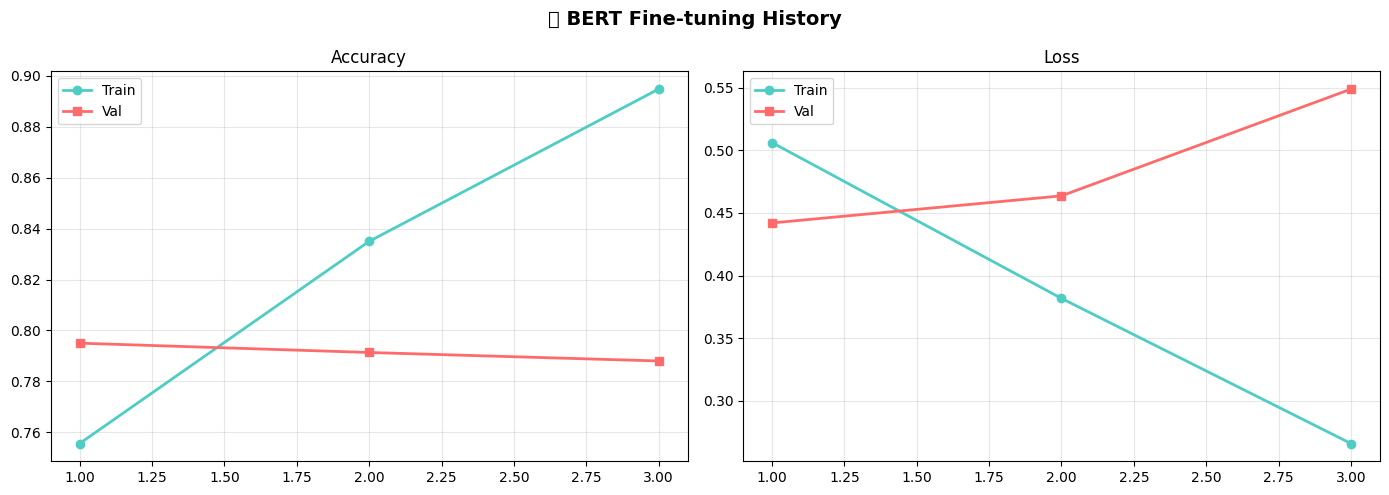

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT model saved in bert_sentiment_model/


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📱 Device : {device}")

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2,
    output_attentions=False, output_hidden_states=False)
bert_model.to(device)

bert_optimizer = optim.AdamW(bert_model.parameters(),
                              lr=BERT_LR, eps=1e-8, weight_decay=0.01)

def train_bert_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for i, batch in enumerate(loader):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        lbl   = batch['label'].to(device)

        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask, labels=lbl)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds   = torch.argmax(out.logits, dim=1)
        correct += (preds == lbl).sum().item()
        total   += lbl.size(0)

        if (i + 1) % 100 == 0:
            print(f"   batch {i+1}/{len(loader)} "
                  f"loss={total_loss/(i+1):.4f} "
                  f"acc={correct/total:.4f}")

    return total_loss / len(loader), correct / total

def evaluate_bert(model, loader, device):
    model.eval()
    preds_all, labels_all, total_loss = [], [], 0
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=lbl)
            total_loss  += out.loss.item()
            preds_all.extend(torch.argmax(out.logits, 1).cpu().numpy())
            labels_all.extend(lbl.cpu().numpy())
    return (total_loss / len(loader),
            np.array(preds_all), np.array(labels_all))

bert_train_losses, bert_val_losses = [], []
bert_train_accs,   bert_val_accs   = [], []

print(f"\n🚀 Fine-tuning BERT ({BERT_EPOCHS} epochs) …")
for epoch in range(BERT_EPOCHS):
    print(f"\n{'='*50}  Epoch {epoch+1}/{BERT_EPOCHS}")
    tr_loss, tr_acc = train_bert_epoch(bert_model, train_loader,
                                        bert_optimizer, device)
    vl_loss, vl_preds, vl_lbls = evaluate_bert(bert_model,
                                                val_loader, device)
    vl_acc = accuracy_score(vl_lbls, vl_preds)

    bert_train_losses.append(tr_loss); bert_val_losses.append(vl_loss)
    bert_train_accs.append(tr_acc);   bert_val_accs.append(vl_acc)
    print(f"  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}")
    print(f"  Val    loss={vl_loss:.4f}  acc={vl_acc:.4f}")

# Test evaluation
_, y_pred_bert, y_true_bert = evaluate_bert(bert_model, test_loader, device)
bert_acc = accuracy_score(y_true_bert, y_pred_bert)
bert_f1  = f1_score(y_true_bert, y_pred_bert)

model_results['BERT'] = {
    'accuracy' : bert_acc,
    'f1_score' : bert_f1,
    'precision': precision_score(y_true_bert, y_pred_bert),
    'recall'   : recall_score(y_true_bert, y_pred_bert)
}

print(f"\n✅ BERT  Accuracy={bert_acc:.4f}  F1={bert_f1:.4f}")
print(classification_report(y_true_bert, y_pred_bert,
                             target_names=['Negative','Positive']))

# BERT history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 BERT Fine-tuning History', fontsize=14, fontweight='bold')
ep = range(1, BERT_EPOCHS+1)
axes[0].plot(ep, bert_train_accs, 'o-', color='#4ECDC4', label='Train', lw=2)
axes[0].plot(ep, bert_val_accs,   's-', color='#FF6B6B', label='Val',   lw=2)
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, bert_train_losses, 'o-', color='#4ECDC4', label='Train', lw=2)
axes[1].plot(ep, bert_val_losses,   's-', color='#FF6B6B', label='Val',   lw=2)
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bert_history.png', dpi=150, bbox_inches='tight')
plt.show()

bert_model.save_pretrained('bert_sentiment_model')
bert_tokenizer.save_pretrained('bert_sentiment_model')
print("✅ BERT model saved in bert_sentiment_model/")

📥 Loading all-MiniLM-L6-v2 …


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,545 (1.39 MB)

 Trainable params: 363,009 (1.38 MB)

 Non-trainable params: 1,536 (6.00 KB)


🚀 Training Sentence Transformer classifier …
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5528 - loss: 0.8151 - val_accuracy: 0.6790 - val_loss: 0.6866 - learning_rate: 0.0010
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6683 - loss: 0.6376 - val_accuracy: 0.7160 - val_loss: 0.6837 - learning_rate: 0.0010
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7068 - loss: 0.5911 - val_accuracy: 0.7415 - val_loss: 0.6818 - learning_rate: 0.0010
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7227 - loss: 0.5631 - val_accuracy: 0.7545 - val_loss: 0.6804 - learning_rate: 0.0010
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7372 - loss: 0.5388 - val_accuracy: 0.7520 - val_loss: 0.6792 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

✅ SentenceTransformer  Accuracy=0.7425  F1=0.7457
              precision    recall  f1-score   support

    Negati

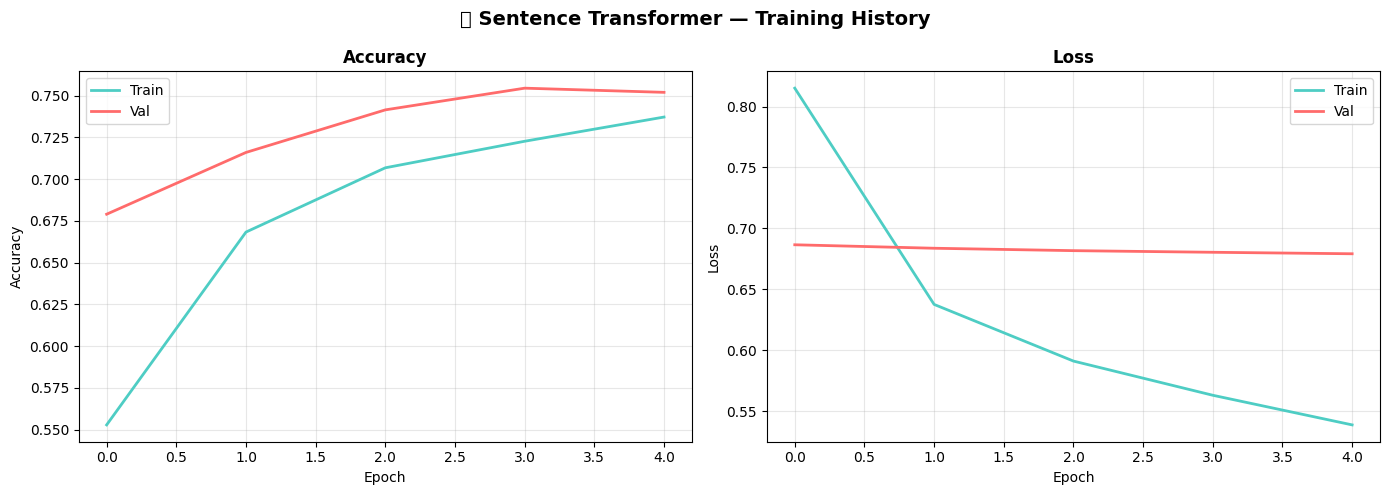

✅ Plot saved : st_history.png
✅ sentence_transformer_classifier.h5 saved!


In [ ]:
ST_SAMPLE = 10_000
print("📥 Loading all-MiniLM-L6-v2 …")
st_encoder = SentenceTransformer('all-MiniLM-L6-v2')

st_idx = np.random.choice(len(X_train), ST_SAMPLE, replace=False)
X_st_tr  = X_train[st_idx];  y_st_tr  = y_train[st_idx]
X_st_val = X_val[:2000];      y_st_val = y_val[:2000]
X_st_te  = X_test[:2000];     y_st_te  = y_test[:2000]

print(f"⚙️  Encoding {len(X_st_tr):,} training sentences …")
Xst_tr_enc  = st_encoder.encode(X_st_tr.tolist(),
                                  batch_size=256, show_progress_bar=True)
Xst_val_enc = st_encoder.encode(X_st_val.tolist(),
                                  batch_size=256, show_progress_bar=True)
Xst_te_enc  = st_encoder.encode(X_st_te.tolist(),
                                  batch_size=256, show_progress_bar=True)

print(f"✅ Embedding dim : {Xst_tr_enc.shape[1]}")

# Classifier on top
def build_st_classifier(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu'), BatchNormalization(), Dropout(0.4),
        Dense(256, activation='relu'), BatchNormalization(), Dropout(0.3),
        Dense(128, activation='relu'), Dropout(0.2),
        Dense(1,   activation='sigmoid')
    ])
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

st_clf = build_st_classifier(Xst_tr_enc.shape[1])
st_clf.summary()

cb_st = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

print("\n🚀 Training Sentence Transformer classifier …")
st_history = st_clf.fit(
    Xst_tr_enc, y_st_tr,
    validation_data=(Xst_val_enc, y_st_val),
    epochs=5, batch_size=4096,
    callbacks=cb_st, verbose=1
)

y_pred_st = (st_clf.predict(Xst_te_enc) > 0.5).astype(int).flatten()
st_acc = accuracy_score(y_st_te, y_pred_st)
st_f1  = f1_score(y_st_te, y_pred_st)

model_results['Sentence Transformer'] = {
    'accuracy' : st_acc,
    'f1_score' : st_f1,
    'precision': precision_score(y_st_te, y_pred_st),
    'recall'   : recall_score(y_st_te, y_pred_st)
}

print(f"\n✅ SentenceTransformer  Accuracy={st_acc:.4f}  F1={st_f1:.4f}")
print(classification_report(y_st_te, y_pred_st,
                             target_names=['Negative','Positive']))

plot_history(st_history, 'Sentence Transformer', 'st_history.png')
st_clf.save('sentence_transformer_classifier.h5')
print("✅ sentence_transformer_classifier.h5 saved!")

In [ ]:
# Custom Attention Layer
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attn_W', shape=(input_shape[-1], 1),
            initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(
            name='attn_b', shape=(input_shape[1], 1),
            initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(
                tf.keras.backend.dot(x, self.W) + self.b)
        a   = tf.keras.backend.softmax(e, axis=1)
        out = x * a
        return tf.keras.backend.sum(out, axis=1)

    def get_config(self):
        return super().get_config()

def build_hybrid_model(vocab_size, emb_dim, max_len, emb_matrix=None):
    inp = Input(shape=(max_len,))

    if emb_matrix is not None:
        emb = Embedding(vocab_size+1, emb_dim,
                        weights=[emb_matrix],
                        input_length=max_len,
                        trainable=True)(inp)
    else:
        emb = Embedding(vocab_size+1, emb_dim,
                        input_length=max_len)(inp)

    # ── CNN branch
    c2 = Conv1D(128, 2, activation='relu', padding='same')(emb)
    c3 = Conv1D(128, 3, activation='relu', padding='same')(emb)
    c4 = Conv1D(128, 4, activation='relu', padding='same')(emb)
    cnn_out = Concatenate()([c2, c3, c4])
    cnn_out = Dropout(0.3)(cnn_out)

    # ── BiLSTM branch
    lstm_out = Bidirectional(
        LSTM(128, return_sequences=True,
             dropout=0.2, recurrent_dropout=0.1))(emb)
    lstm_out = Dropout(0.3)(lstm_out)

    # ── Merge CNN + BiLSTM
    merged = Concatenate()([cnn_out, lstm_out])

    # ── BiGRU on merged
    gru_out = Bidirectional(
        GRU(64, return_sequences=True, dropout=0.2))(merged)

    # ── Attention
    attended = AttentionLayer()(gru_out)

    # ── Classifier head
    x = Dense(256, activation='relu')(attended)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64,  activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("📊 Building Hybrid CNN + BiLSTM + BiGRU + Attention …")
hybrid_model = build_hybrid_model(MAX_FEATURES, EMBEDDING_DIM,
                                   MAX_LEN, embedding_matrix)
hybrid_model.summary()
print(f"\n📊 Total params : {hybrid_model.count_params():,}")

📊 Building Hybrid CNN + BiLSTM + BiGRU + Attention …


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 50, 100)   │  5,000,100 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 128)   │     25,728 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 50, 128)   │     38,528 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 50, 128)   │     51,328 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 50, 384)   │          0 │ conv1d_4[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 50, 256)   │    234,496 │ embedding_4[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 50, 384)   │          0 │ concatenate_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 50, 256)   │          0 │ bidirectional_4[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 50, 640)   │          0 │ dropout_16[0][0], │
│ (Concatenate)       │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 50, 128)   │    271,104 │ concatenate_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 128)       │        178 │ bidirectional_5[… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 256)       │     33,024 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 128)       │     32,896 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 128)       │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 64)        │      8,256 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,696,727 (21.73 MB)

 Trainable params: 5,696,215 (21.73 MB)

 Non-trainable params: 512 (2.00 KB)


📊 Total params : 5,696,727


🚀 Training Hybrid Model …
Epoch 1/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.6761 - loss: 0.5932
Epoch 1: val_accuracy improved from None to 0.77731, saving model to best_hybrid_model.h5



Epoch 1: finished saving model to best_hybrid_model.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 135s 442ms/step - accuracy: 0.7271 - loss: 0.5385 - val_accuracy: 0.7773 - val_loss: 0.6194 - learning_rate: 0.0010
Epoch 2/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7849 - loss: 0.4641
Epoch 2: val_accuracy did not improve from 0.77731
273/273 ━━━━━━━━━━━━━━━━━━━━ 117s 430ms/step - accuracy: 0.7898 - loss: 0.4559 - val_accuracy: 0.7670 - val_loss: 0.4923 - learning_rate: 0.0010
Epoch 3/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8163 - loss: 0.4096
Epoch 3: val_accuracy improved from 0.77731 to 0.78926, saving model to best_hybrid_model.h5



Epoch 3: finished saving model to best_hybrid_model.h5
273/273 ━━━━━━━━━━━━━━━━━━━━ 118s 431ms/step - accuracy: 0.8162 - loss: 0.4094 - val_accuracy: 0.7893 - val_loss: 0.4509 - learning_rate: 0.0010
Epoch 4/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.8414 - loss: 0.3624
Epoch 4: val_accuracy did not improve from 0.78926
273/273 ━━━━━━━━━━━━━━━━━━━━ 143s 437ms/step - accuracy: 0.8397 - loss: 0.3657 - val_accuracy: 0.7825 - val_loss: 0.4679 - learning_rate: 0.0010
Epoch 5/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8591 - loss: 0.3251
Epoch 5: val_accuracy did not improve from 0.78926
273/273 ━━━━━━━━━━━━━━━━━━━━ 114s 418ms/step - accuracy: 0.8581 - loss: 0.3290 - val_accuracy: 0.7801 - val_loss: 0.5007 - learning_rate: 0.0010
Epoch 6/25
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8738 - loss: 0.2959
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_accuracy did not improve from 0.78926
273/273 ━━━━━━━

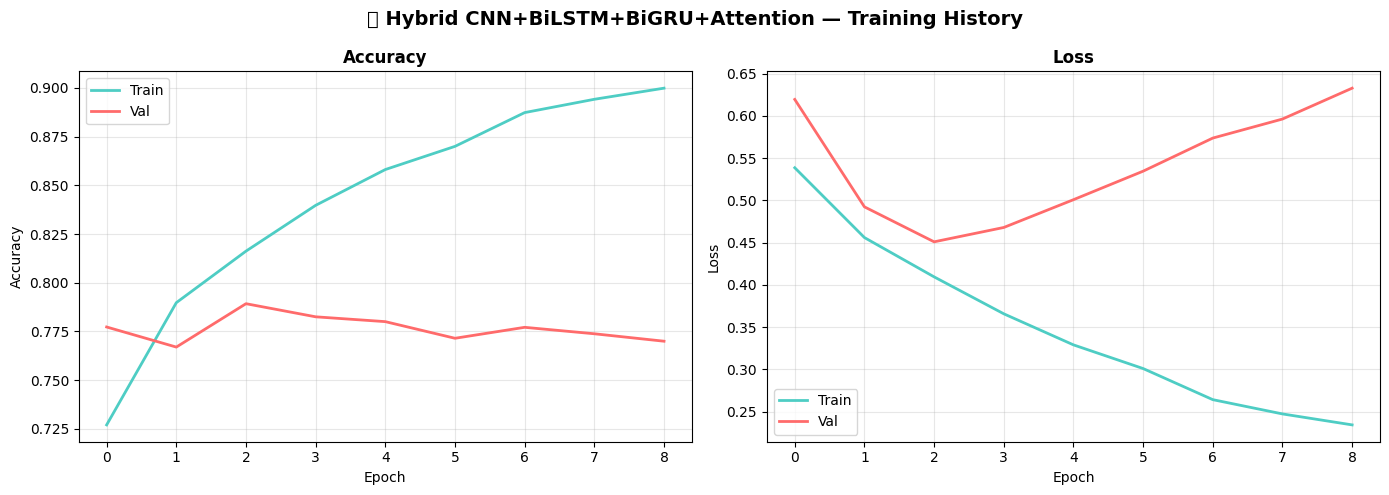

✅ Plot saved : hybrid_history.png


In [ ]:
cb_hybrid = [
    EarlyStopping(monitor='val_loss', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_hybrid_model.h5',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("🚀 Training Hybrid Model …")
hybrid_history = hybrid_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5, batch_size=4096,
    callbacks=cb_hybrid, verbose=1
)

y_pred_hybrid = (hybrid_model.predict(X_test_pad, batch_size=512) > 0.5
                 ).astype(int).flatten()
hybrid_acc = accuracy_score(y_test, y_pred_hybrid)
hybrid_f1  = f1_score(y_test, y_pred_hybrid)

model_results['Hybrid CNN+BiLSTM+Attn'] = {
    'accuracy' : hybrid_acc,
    'f1_score' : hybrid_f1,
    'precision': precision_score(y_test, y_pred_hybrid),
    'recall'   : recall_score(y_test, y_pred_hybrid)
}

print(f"\n✅ Hybrid  Accuracy={hybrid_acc:.4f}  F1={hybrid_f1:.4f}")
print(classification_report(y_test, y_pred_hybrid,
                             target_names=['Negative','Positive']))

plot_history(hybrid_history,
             'Hybrid CNN+BiLSTM+BiGRU+Attention',
             'hybrid_history.png')

hybrid_model.save('hybrid_model.h5')

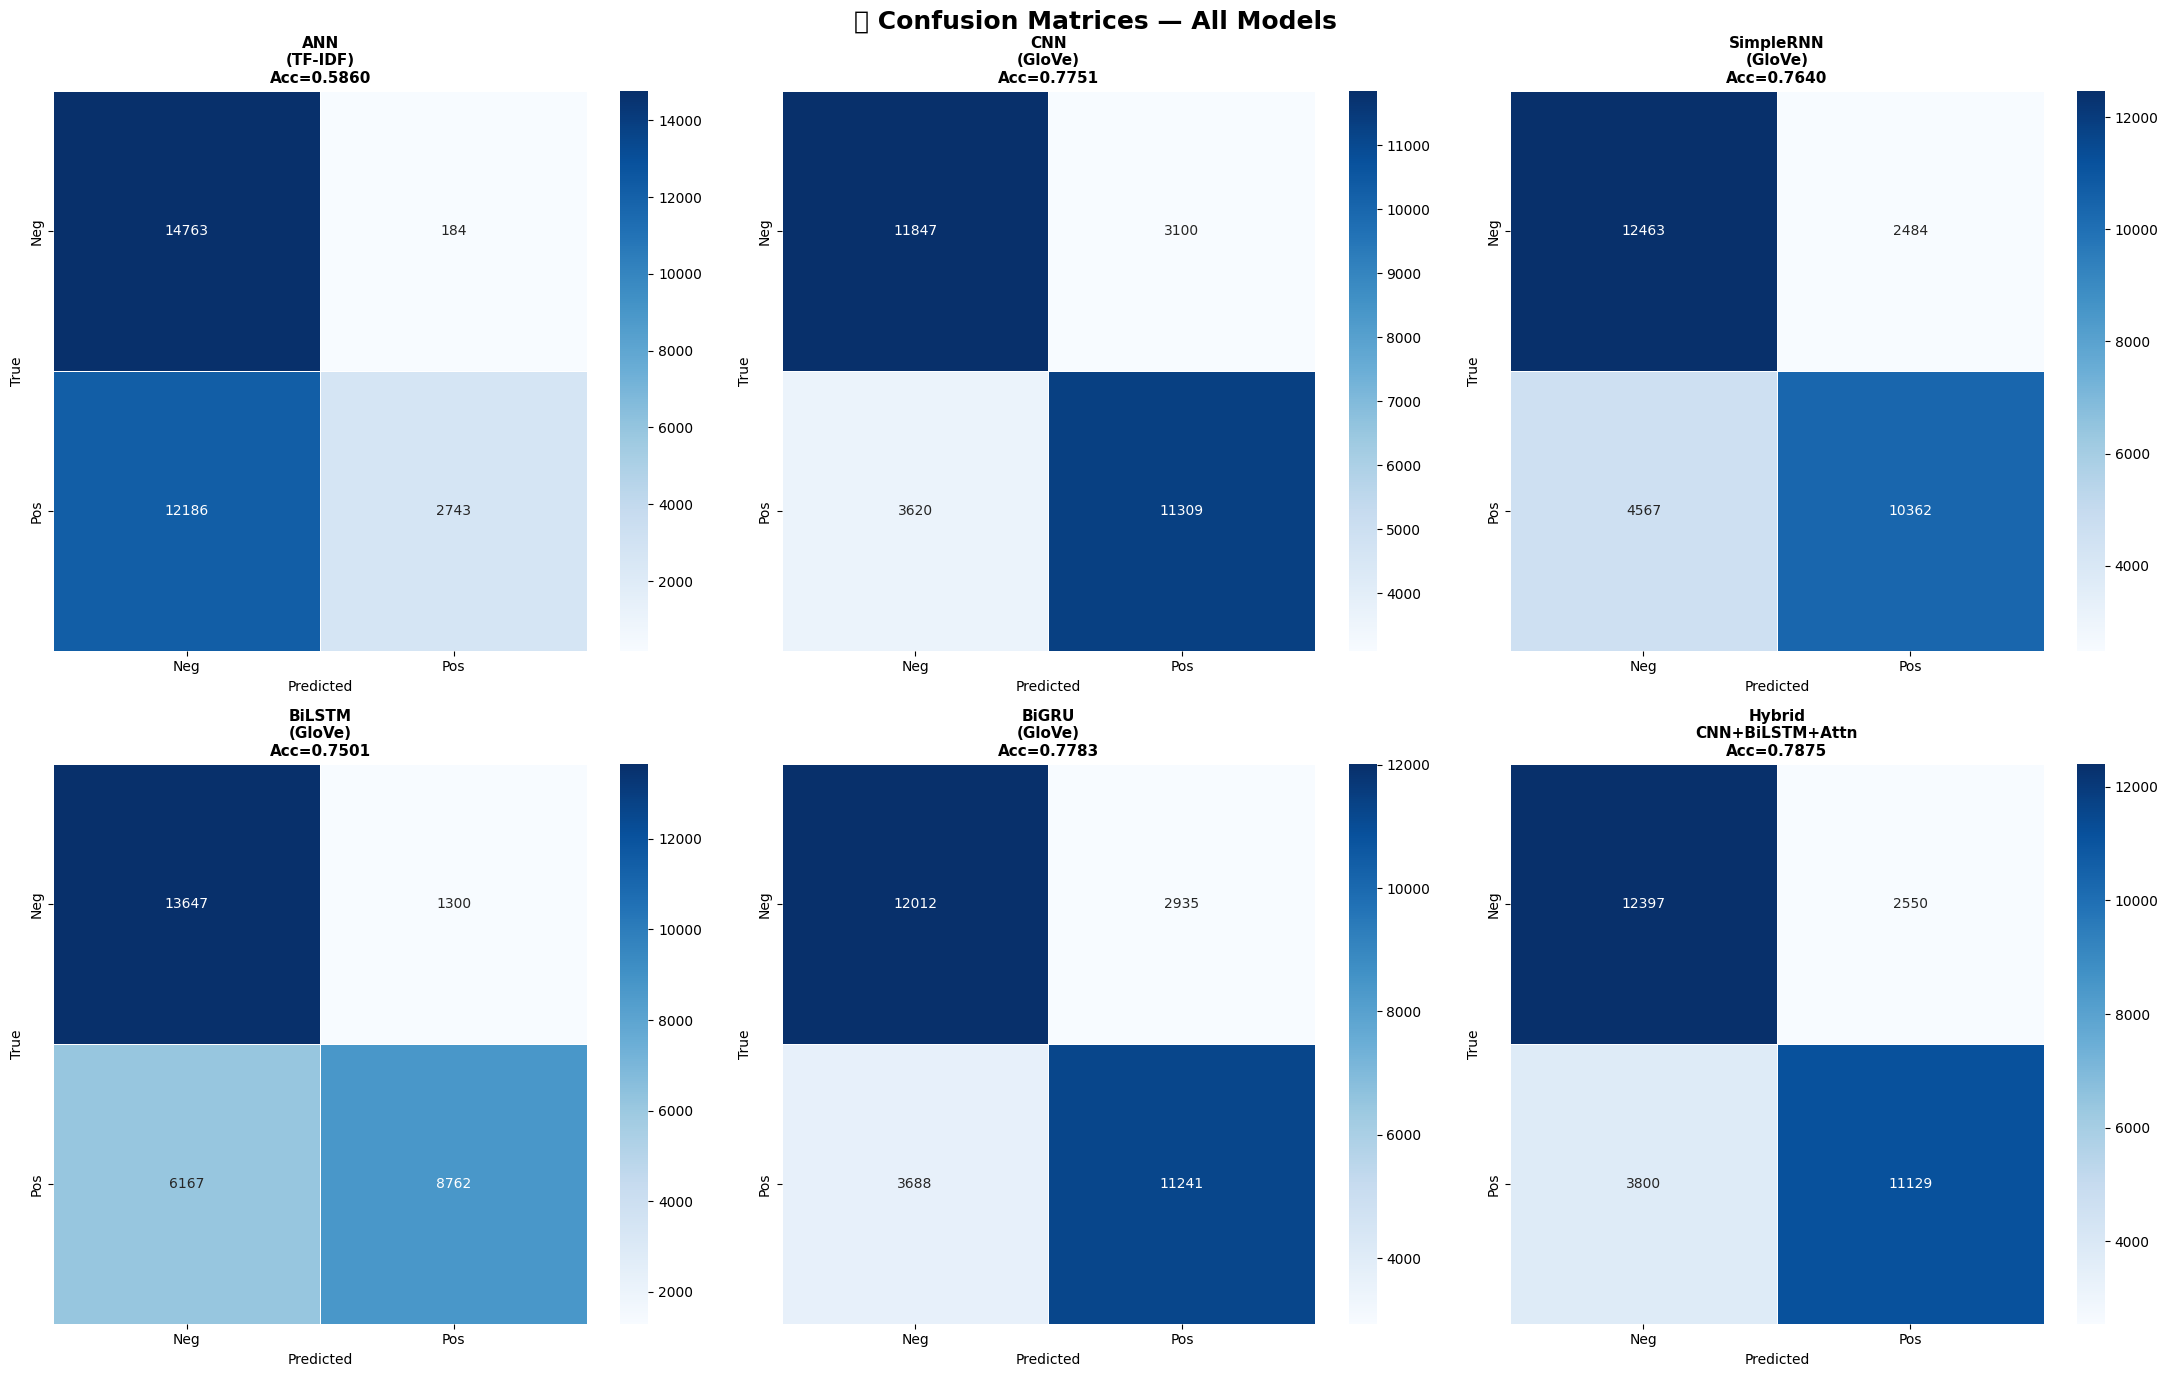

In [ ]:
all_preds = [
    ('ANN\n(TF-IDF)',         y_pred_ann,    y_test),
    ('CNN\n(GloVe)',           y_pred_cnn,    y_test),
    ('SimpleRNN\n(GloVe)',     y_pred_rnn,    y_test),
    ('BiLSTM\n(GloVe)',        y_pred_lstm,   y_test),
    ('BiGRU\n(GloVe)',         y_pred_gru,    y_test),
    ('Hybrid\nCNN+BiLSTM+Attn',y_pred_hybrid, y_test),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('🎯 Confusion Matrices — All Models',
             fontsize=18, fontweight='bold')

for idx, (name, preds, true) in enumerate(all_preds):
    ax = axes[idx // 3][idx % 3]
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'],
                yticklabels=['Neg','Pos'],
                ax=ax, linewidths=0.5)
    acc = accuracy_score(true, preds)
    ax.set_title(f'{name}\nAcc={acc:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


📋 Model Leaderboard:
                        accuracy  f1_score  precision  recall
Hybrid CNN+BiLSTM+Attn    0.7875    0.7780     0.8136  0.7455
BERT                      0.7807    0.7916     0.7778  0.8059
BiGRU (GloVe)             0.7783    0.7724     0.7930  0.7530
CNN (GloVe)               0.7751    0.7709     0.7849  0.7575
SimpleRNN (GloVe)         0.7640    0.7461     0.8066  0.6941
BiLSTM (GloVe)            0.7501    0.7012     0.8708  0.5869
Sentence Transformer      0.7425    0.7457     0.7619  0.7302
ANN (TF-IDF)              0.5860    0.3072     0.9371  0.1837


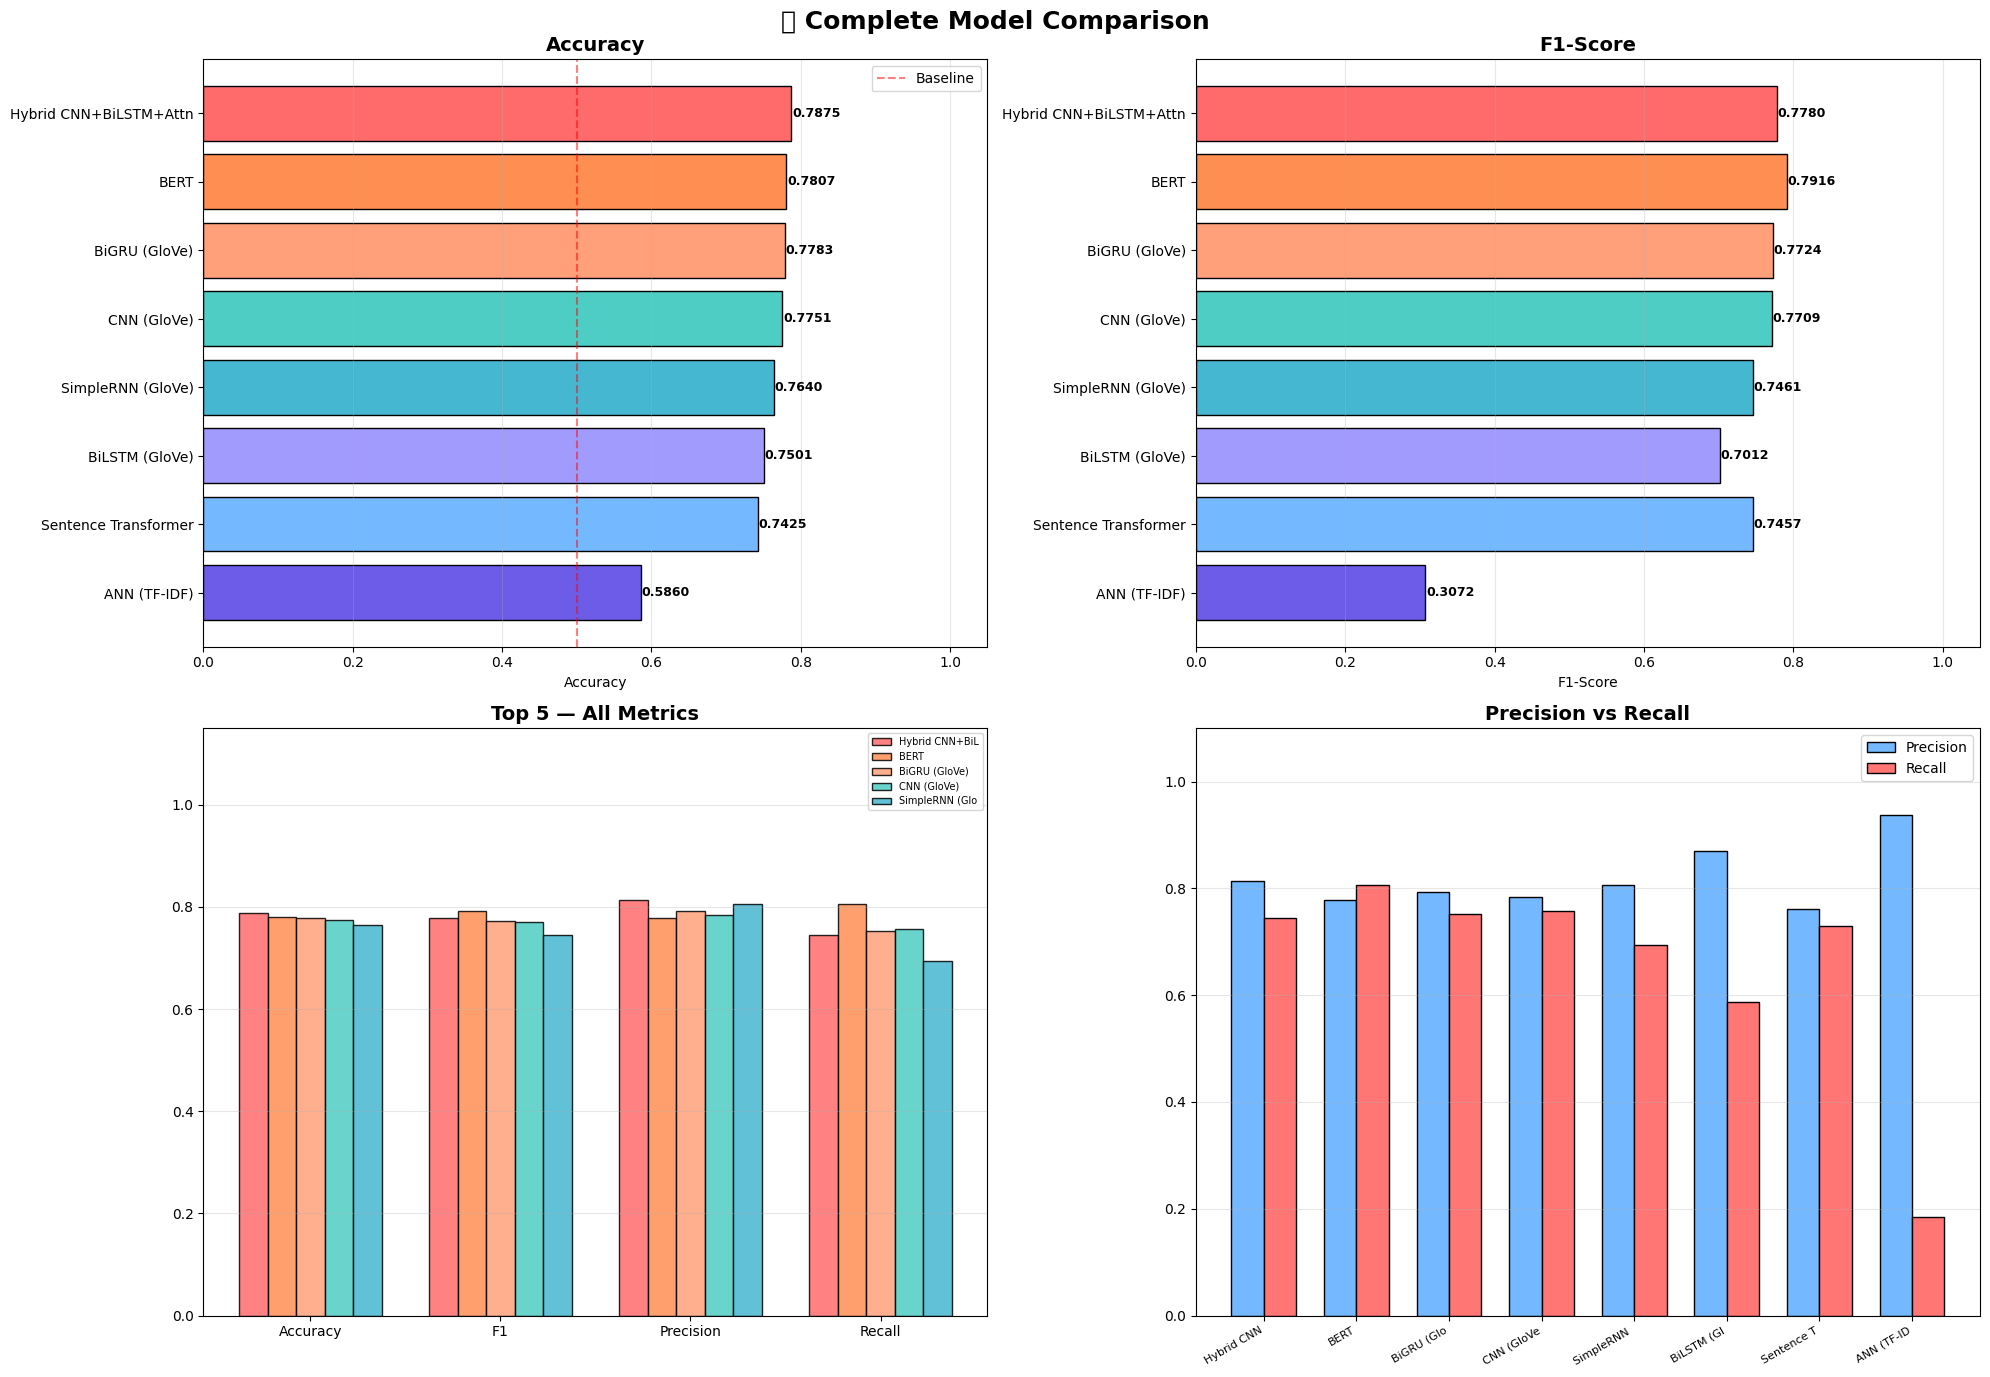

In [ ]:
results_df = (pd.DataFrame(model_results).T
                .apply(pd.to_numeric)
                .sort_values('accuracy', ascending=False))

print("\n📋 Model Leaderboard:")
print(results_df.round(4).to_string())

colors_bar = ['#FF6B6B','#FF8E53','#FFA07A',
              '#4ECDC4','#45B7D1','#A29BFE',
              '#74B9FF','#6C5CE7','#00B894'][:len(results_df)]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('📊 Complete Model Comparison',
             fontsize=18, fontweight='bold')

# 1. Accuracy
ax = axes[0, 0]
bars = ax.barh(results_df.index[::-1],
               results_df['accuracy'][::-1],
               color=colors_bar[::-1], edgecolor='black')
ax.set_title('Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Accuracy')
ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='Baseline')
for bar, val in zip(bars, results_df['accuracy'][::-1]):
    ax.text(bar.get_width()+0.001,
            bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, 1.05); ax.legend(); ax.grid(axis='x', alpha=0.3)

# 2. F1-Score
ax = axes[0, 1]
bars = ax.barh(results_df.index[::-1],
               results_df['f1_score'][::-1],
               color=colors_bar[::-1], edgecolor='black')
ax.set_title('F1-Score', fontsize=14, fontweight='bold')
ax.set_xlabel('F1-Score')
for bar, val in zip(bars, results_df['f1_score'][::-1]):
    ax.text(bar.get_width()+0.001,
            bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, 1.05); ax.grid(axis='x', alpha=0.3)

# 3. Top-5 all metrics
ax = axes[1, 0]
top5  = results_df.head(5)
mets  = ['accuracy','f1_score','precision','recall']
xpos  = np.arange(len(mets)); w = 0.15
for i, (nm, row) in enumerate(top5.iterrows()):
    ax.bar(xpos + i*w, [row[m] for m in mets],
           w, label=nm[:14], color=colors_bar[i],
           alpha=0.85, edgecolor='black')
ax.set_title('Top 5 — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(xpos + w*2)
ax.set_xticklabels(['Accuracy','F1','Precision','Recall'])
ax.set_ylim(0, 1.15); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

# 4. Precision vs Recall
ax = axes[1, 1]
xp = np.arange(len(results_df)); w2 = 0.35
ax.bar(xp - w2/2, results_df['precision'], w2,
       label='Precision', color='#74B9FF', edgecolor='black')
ax.bar(xp + w2/2, results_df['recall'],    w2,
       label='Recall',    color='#FF7675', edgecolor='black')
ax.set_title('Precision vs Recall', fontsize=14, fontweight='bold')
ax.set_xticks(xp)
ax.set_xticklabels([n[:10] for n in results_df.index],
                   rotation=30, ha='right', fontsize=8)
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Helper: save Keras model as dict
def keras_to_dict(model):
    return {
        'architecture': model.to_json(),
        'weights'     : model.get_weights()
    }

complete_pipeline = {
    # ── Metadata
    'best_model'   : results_df['accuracy'].idxmax(),
    'model_results': {
        k: {mk: float(mv) for mk, mv in v.items()}
        for k, v in model_results.items()
    },
    # ── Config
    'max_features' : MAX_FEATURES,
    'max_len'      : MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'bert_max_len' : BERT_MAX_LEN,
    # ── Vectorizers / Tokenizers
    'tfidf_vectorizer': tfidf_vectorizer,
    'keras_tokenizer' : keras_tokenizer,
    # ── Label mapping
    'label_mapping': {0: 'Negative', 1: 'Positive'},
    # ── Keras models
    'ann'    : keras_to_dict(ann_model),
    'cnn'    : keras_to_dict(cnn_model),
    'rnn'    : keras_to_dict(rnn_model),
    'lstm'   : keras_to_dict(lstm_model),
    'gru'    : keras_to_dict(gru_model),
    'hybrid' : keras_to_dict(hybrid_model),
    'st_clf' : keras_to_dict(st_clf),
    # ── Preprocessing config
    'preprocessing': {
        'remove_urls': True, 'remove_mentions': True,
        'lowercase'  : True, 'remove_specials': True,
        'lemmatize'  : True, 'remove_stopwords': True
    }
}

with open('complete_sentiment_pipeline.pkl', 'wb') as f:
    pickle.dump(complete_pipeline, f)

size = os.path.getsize('complete_sentiment_pipeline.pkl') / (1024**2)
print(f"✅ complete_sentiment_pipeline.pkl  ({size:.1f} MB)")

# Individual saves
ann_model.save('ann_model.h5')
cnn_model.save('cnn_model.h5')
rnn_model.save('rnn_model.h5')
lstm_model.save('lstm_model.h5')
gru_model.save('gru_model.h5')
hybrid_model.save('hybrid_model.h5')
st_clf.save('sentence_transformer_classifier.h5')

with open('tfidf_vectorizer.pkl',  'wb') as f: pickle.dump(tfidf_vectorizer, f)
with open('keras_tokenizer.pkl',   'wb') as f: pickle.dump(keras_tokenizer,  f)

config = {
    'max_features': MAX_FEATURES,
    'max_len'     : MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'bert_max_len': BERT_MAX_LEN,
    'model_results': complete_pipeline['model_results']
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("\n✅ All files saved:")
for fn in ['ann_model.h5','cnn_model.h5','rnn_model.h5',
           'lstm_model.h5','gru_model.h5','hybrid_model.h5',
           'best_hybrid_model.h5','sentence_transformer_classifier.h5',
           'tfidf_vectorizer.pkl','keras_tokenizer.pkl',
           'model_config.json','complete_sentiment_pipeline.pkl']:
    if os.path.exists(fn):
        sz = os.path.getsize(fn)/(1024**2)
        print(f"   ✅ {fn:<48} {sz:>7.2f} MB")
    else:
        print(f"   ❌ {fn} — not found")

✅ complete_sentiment_pipeline.pkl  (207.0 MB)



✅ All files saved:
   ✅ ann_model.h5                                      295.05 MB
   ✅ cnn_model.h5                                       61.24 MB
   ✅ rnn_model.h5                                       57.80 MB
   ✅ lstm_model.h5                                      62.15 MB
   ✅ gru_model.h5                                       61.03 MB
   ✅ hybrid_model.h5                                    65.31 MB
   ✅ best_hybrid_model.h5                               65.31 MB
   ✅ sentence_transformer_classifier.h5                  4.21 MB
   ✅ tfidf_vectorizer.pkl                                1.85 MB
   ✅ keras_tokenizer.pkl                                 2.94 MB
   ✅ model_config.json                                   0.00 MB
   ✅ complete_sentiment_pipeline.pkl                   206.97 MB


In [34]:
from tensorflow.keras.models import model_from_json

def load_keras_from_pipeline(pipeline, key):
    obj = pipeline[key]
    m   = model_from_json(obj['architecture'],
                           custom_objects={'AttentionLayer': AttentionLayer})
    m.set_weights(obj['weights'])
    return m

print("📂 Loading pipeline …")
with open('complete_sentiment_pipeline.pkl', 'rb') as f:
    pipe = pickle.load(f)

_tfidf = pipe['tfidf_vectorizer']
_tok   = pipe['keras_tokenizer']
_mlen  = pipe['max_len']
_lmap  = pipe['label_mapping']

_models_cache = {}

def predict_sentiment(text: str, model_name: str = 'hybrid') -> dict:
    cleaned = full_preprocess(text)

    if model_name not in _models_cache:
        _models_cache[model_name] = load_keras_from_pipeline(pipe, model_name)

    mdl = _models_cache[model_name]

    if model_name == 'ann':
        feat = _tfidf.transform([cleaned])
        prob = float(mdl.predict(feat, verbose=0)[0][0])
    else:
        seq    = _tok.texts_to_sequences([cleaned])
        padded = pad_sequences(seq, maxlen=_mlen,
                               padding='post', truncating='post')
        prob   = float(mdl.predict(padded, verbose=0)[0][0])

    pred       = 1 if prob > 0.5 else 0
    confidence = prob if pred == 1 else 1 - prob

    return {
        'text'                : text,
        'cleaned_text'        : cleaned,
        'sentiment'           : _lmap[pred],
        'sentiment_code'      : pred,
        'probability_positive': round(prob, 4),
        'probability_negative': round(1 - prob, 4),
        'confidence'          : round(confidence, 4),
        'model_used'          : model_name
    }

# ---- Test ----
samples = [
    "I absolutely love this! It's amazing and wonderful!",
    "This is terrible. I hate it. Worst experience ever.",
    "The weather is nice today, feeling great!",
    "I'm so disappointed, nothing works. Very frustrating.",
    "Best movie I've seen this year — highly recommended!",
    "Completely boring and a waste of time.",
]

print("\n🔮 Inference Test Results")
print("=" * 72)
for text in samples:
    r   = predict_sentiment(text, model_name='hybrid')
    bar = "█" * int(r['confidence'] * 20)
    print(f"📝 {r['text'][:60]}")
    print(f"   → {r['sentiment']:<18} conf={r['confidence']:.4f} [{bar}]")
    print()

📂 Loading pipeline …

🔮 Inference Test Results
📝 I absolutely love this! It's amazing and wonderful!
   → Positive           conf=0.9538 [███████████████████]

📝 This is terrible. I hate it. Worst experience ever.
   → Negative           conf=0.9732 [███████████████████]

📝 The weather is nice today, feeling great!
   → Positive           conf=0.8530 [█████████████████]

📝 I'm so disappointed, nothing works. Very frustrating.
   → Negative           conf=0.9821 [███████████████████]

📝 Best movie I've seen this year — highly recommended!
   → Positive           conf=0.9265 [██████████████████]

📝 Completely boring and a waste of time.
   → Negative           conf=0.7479 [██████████████]



In [35]:
from google.colab import files

# ---- Leaderboard ----
print("🏆 FINAL LEADERBOARD")
print("=" * 65)
print(f"{'Rk':<5} {'Model':<32} {'Accuracy':>10} {'F1':>10}")
print("=" * 65)
medals = ['🥇','🥈','🥉'] + [f' {i}.' for i in range(4, 20)]
for rank, (name, row) in enumerate(results_df.iterrows(), 1):
    print(f"{medals[rank-1]:<5} {name:<32} "
          f"{row['accuracy']:>10.4f} {row['f1_score']:>10.4f}")
print("=" * 65)
print(f"\n🥇 Best : {results_df.index[0]}  "
      f"Acc={results_df['accuracy'].iloc[0]:.4f}")

# ---- ZIP ----
zip_name   = 'sentiment_analysis_complete.zip'
to_zip     = [
    'complete_sentiment_pipeline.pkl',
    'tfidf_vectorizer.pkl', 'keras_tokenizer.pkl',
    'ann_model.h5', 'cnn_model.h5', 'rnn_model.h5',
    'lstm_model.h5', 'gru_model.h5', 'hybrid_model.h5',
    'best_hybrid_model.h5', 'sentence_transformer_classifier.h5',
    'model_config.json',
    'eda_visualization.png', 'wordclouds.png',
    'preprocessing_analysis.png', 'tfidf_analysis.png',
    'word2vec_tsne.png', 'confusion_matrices.png',
    'model_comparison.png',
    'ann_history.png','cnn_history.png','rnn_history.png',
    'lstm_history.png','gru_history.png','hybrid_history.png',
    'bert_history.png','st_history.png',
]

print(f"\n📦 Creating {zip_name} …")
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in to_zip:
        if os.path.exists(fn):
            zf.write(fn)
            print(f"   ✅ {fn}")
        else:
            print(f"   ⚠️  skipped (not found): {fn}")

zsize = os.path.getsize(zip_name) / (1024**2)
print(f"\n📦 ZIP ready : {zip_name}  ({zsize:.1f} MB)")

print("\n📥 Downloading ZIP …")
files.download(zip_name)

print("\n📥 Downloading main pipeline PKL …")
files.download('complete_sentiment_pipeline.pkl')

🏆 FINAL LEADERBOARD
Rk    Model                              Accuracy         F1
🥇     Hybrid CNN+BiLSTM+Attn               0.7875     0.7780
🥈     BERT                                 0.7807     0.7916
🥉     BiGRU (GloVe)                        0.7783     0.7724
 4.   CNN (GloVe)                          0.7751     0.7709
 5.   SimpleRNN (GloVe)                    0.7640     0.7461
 6.   BiLSTM (GloVe)                       0.7501     0.7012
 7.   Sentence Transformer                 0.7425     0.7457
 8.   ANN (TF-IDF)                         0.5860     0.3072

🥇 Best : Hybrid CNN+BiLSTM+Attn  Acc=0.7875

📦 Creating sentiment_analysis_complete.zip …
   ✅ complete_sentiment_pipeline.pkl
   ✅ tfidf_vectorizer.pkl
   ✅ keras_tokenizer.pkl
   ✅ ann_model.h5
   ✅ cnn_model.h5
   ✅ rnn_model.h5
   ✅ lstm_model.h5
   ✅ gru_model.h5
   ✅ hybrid_model.h5
   ✅ best_hybrid_model.h5
   ✅ sentence_transformer_classifier.h5
   ✅ model_config.json
   ✅ eda_visualization.png
   ✅ wordclouds.png
   ✅

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Downloading main pipeline PKL …


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>